# Era 3 — The Debate & Trump's Second Assassination Attempt
## September 10–15, 2024

Two seismic events in five days.

On **September 10** Trump and Harris faced off in the ABC debate — widely seen as a strong night for Harris.
Five days later, on **September 15**, a gunman opened fire at Trump's golf course in West Palm Beach: the **second assassination attempt** of the campaign.

Together they created a rare **narrative whiplash**: the debate boosted Harris, the assassination attempt pivoted sympathy back toward Trump.
This notebook asks — across every data source — what happened in those five days, and did the second event undo the first?

| Event | Date | Nature |
|---|---|---|
| Trump–Harris debate (ABC) | Sep 10, 2024 | Performative — planned |
| 2nd assassination attempt (golf course, Ryan Wesley Routh) | Sep 15, 2024 | Shocking — unplanned |

**Analytical caveat:** A 3-day pre/post window around the assassination attempt (Sep 12–17) **overlaps** with the post-debate window (Sep 11–13). Results for that window should be read as the *combined* aftermath of both events, not the assassination attempt in isolation.

**Sources:** Bluesky · Reddit · Polymarket · Financial markets (VIX / S&P 500) · Polls · Google Trends · Newspaper sentiment

<!-- toc -->
## Contents
- [0 · Setup & Data Loading](#0-setup--data-loading)
- [1 · The Double Spike — Era Overview](#1-the-double-spike--era-overview)
- [2 · What People Talked About — TF-IDF Term Shifts (Bluesky)](#2-what-people-talked-about--tf-idf-term-shifts-bluesky)
- [3 · Who Was Talking — Buzz-Group Composition Shift](#3-who-was-talking--buzz-group-composition-shift)
- [4 · Polls — September as Harris's Peak Month](#4-polls--september-as-harriss-peak-month)
- [5 · Assassination Fatigue — Financial Markets](#5-assassination-fatigue--financial-markets)
- [6 · Partisan Newspaper Framing of the Debate](#6-partisan-newspaper-framing-of-the-debate)
- [7 · Google Trends — Transient Attention Spikes](#7-google-trends--transient-attention-spikes)
- [8 · Cross-Source Synthesis — The 5-Day Reversal](#8-cross-source-synthesis--the-5-day-reversal)

## 0 · Setup & Data Loading

In [1]:
import sys, warnings
warnings.filterwarnings('ignore')
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from sklearn.feature_extraction.text import TfidfVectorizer

sys.path.insert(0, '../..')
from house_style import (
    apply_style, styled_fig, style_ax, add_events,
    REPUBLICAN, DEMOCRAT, NEUTRAL, ACCENT,
    TEXT_PRIMARY, TEXT_MUTED, BG_DARK, BG_PANEL, SPINE_COLOR, PALETTE,
    EVENTS, EVENT_PALETTE
)
apply_style()

# ── Era constants ──────────────────────────────────────────────────────────────
DEBATE    = pd.Timestamp('2024-09-10')
ATTEMPT2  = pd.Timestamp('2024-09-15')
ERA_START = pd.Timestamp('2024-09-01')
ERA_END   = pd.Timestamp('2024-09-25')
WINDOW    = 3  # days each side for pre/post analysis

ERA_EVENTS = [
    ('Trump–Harris Debate', '2024-09-10', NEUTRAL),
    ('2nd Assassination Attempt', '2024-09-15', '#c0392b'),
]

BUZZ_COLORS = {'TrumpBuzz': REPUBLICAN, 'HarrisBuzz': DEMOCRAT, 'ElectionBuzz': NEUTRAL}
BUZZ_ORDER  = ['TrumpBuzz', 'HarrisBuzz', 'ElectionBuzz']
ROOT        = Path('../../data')

# ── Helper: add era event lines ────────────────────────────────────────────────
def add_era_events(ax, annotate_top=False):
    for lbl, date, color in ERA_EVENTS:
        ax.axvline(pd.Timestamp(date), color=color, linestyle='--', linewidth=2, alpha=0.9, zorder=5)
        if annotate_top:
            ylims = ax.get_ylim()
            ax.text(pd.Timestamp(date) + pd.Timedelta(hours=6),
                    ylims[1] * 0.97, lbl, color=color,
                    fontsize=7, fontweight='bold', va='top')

def era_legend_handles():
    return [
        mlines.Line2D([], [], color=c, linestyle='--', linewidth=2.5, label=lbl)
        for lbl, _, c in ERA_EVENTS
    ]

def get_window(df, date_col, event_date, days=WINDOW):
    pre  = df[(df[date_col] >= event_date - pd.Timedelta(days=days)) &
              (df[date_col] <  event_date)]
    post = df[(df[date_col] >  event_date) &
              (df[date_col] <= event_date + pd.Timedelta(days=days))]
    return pre, post

def top_tfidf(texts, n=15):
    texts = [str(t) for t in texts if str(t).strip()]
    if len(texts) < 5:
        return pd.Series(dtype=float)
    vec = TfidfVectorizer(token_pattern=r'\b\w{3,}\b', min_df=2, max_features=5000)
    mat = vec.fit_transform(texts)
    means = pd.Series(mat.mean(axis=0).A1, index=vec.get_feature_names_out())
    return means.nlargest(n)

def top_tfidf_gained(pre_texts, post_texts, n=15):
    pre_texts  = [str(t) for t in pre_texts  if str(t).strip()]
    post_texts = [str(t) for t in post_texts if str(t).strip()]
    if len(pre_texts) < 5 or len(post_texts) < 5:
        return pd.Series(dtype=float)
    all_texts = pre_texts + post_texts
    labels    = [0]*len(pre_texts) + [1]*len(post_texts)
    vec  = TfidfVectorizer(token_pattern=r'\b\w{3,}\b', min_df=2, max_features=5000)
    mat  = vec.fit_transform(all_texts)
    terms     = np.array(vec.get_feature_names_out())
    pre_idx   = [i for i, l in enumerate(labels) if l == 0]
    post_idx  = [i for i, l in enumerate(labels) if l == 1]
    pre_mean  = np.asarray(mat[pre_idx].mean(axis=0)).ravel()
    post_mean = np.asarray(mat[post_idx].mean(axis=0)).ravel()
    shift     = post_mean - pre_mean
    top_idx   = np.argsort(shift)[-n:][::-1]
    return pd.Series(shift[top_idx], index=terms[top_idx])

print('Setup complete.')

Setup complete.


In [2]:
# ── Bluesky ────────────────────────────────────────────────────────────────────
bsky = pd.read_csv(ROOT / '2_Silver/Bluesky/bluesky_clean.csv')
bsky['date'] = pd.to_datetime(bsky['timestamp'], utc=True, format="mixed").dt.tz_convert(None).dt.normalize()
bsky = bsky.rename(columns={'candidate': 'buzz_group'})
bsky['buzz_group'] = bsky['buzz_group'].fillna('ElectionBuzz')
print(f'Bluesky : {len(bsky):,} rows | {bsky["date"].min().date()} → {bsky["date"].max().date()}')

# ── Reddit posts (posts only — 27 MB; comments file is 744 MB) ─────────────────
reddit = pd.read_parquet(ROOT / '2_Silver/Reddit/reddit_posts_clean.parquet')
reddit['date'] = pd.to_datetime(reddit['created_utc'], utc=True).dt.tz_convert(None).dt.normalize()
reddit = reddit.rename(columns={'candidate': 'buzz_group'})
reddit['buzz_group'] = reddit['buzz_group'].fillna('ElectionBuzz')
print(f'Reddit  : {len(reddit):,} posts | {reddit["date"].min().date()} → {reddit["date"].max().date()}')

# ── Polymarket ─────────────────────────────────────────────────────────────────
poly = pd.read_csv(ROOT / '1_Bronze/Polymarket/polymarket_win_probabilities.csv')
poly['date'] = pd.to_datetime(poly['date'])
poly = poly.rename(columns={'Trump (%)': 'trump_pct', 'Harris (%)': 'harris_pct'})
print(f'Polymarket: {len(poly):,} days | {poly["date"].min().date()} → {poly["date"].max().date()}')

# ── Financial markets ──────────────────────────────────────────────────────────
market = pd.read_csv(ROOT / '1_Bronze/Financials/market.csv')
market['Date'] = pd.to_datetime(market['Date'])
print(f'Market  : {len(market):,} trading days')

# ── Polls ──────────────────────────────────────────────────────────────────────
polls = pd.read_csv(ROOT / '1_Bronze/Polls/wikipedia_polls.csv')
polls['Date'] = pd.to_datetime(polls['Date'])
polls = polls.sort_values('Date').reset_index(drop=True)
print(f'Polls   : {len(polls):,}')

# ── Google Trends ──────────────────────────────────────────────────────────────
trends = pd.read_csv(ROOT / '1_Bronze/google_trends/trends_daily_stitched.csv')
trends['date'] = pd.to_datetime(trends['date'])
print(f'Trends  : {len(trends):,} days')

# ── Newspaper sentiment features (daily × leaning) ────────────────────────────
news_sent = pd.read_csv(ROOT / '2_Silver/Newspapers/sentiment_features_newspapers.csv')
news_sent['date'] = pd.to_datetime(news_sent['date'])
print(f'News    : {len(news_sent):,} days')

# ── Mediacloud daily coverage counts ──────────────────────────────────────────
mc = pd.read_csv(ROOT / '2_Silver/Newspapers/mediacloud_daily.csv')
mc['date'] = pd.to_datetime(mc['date'])
print(f'Mediacloud: {len(mc):,} days')

print('\nAll sources loaded.')

Bluesky : 26,964 rows | 2024-07-05 → 2026-01-19
Reddit  : 105,017 posts | 2024-07-05 → 2024-11-03
Polymarket: 124 days | 2024-07-05 → 2024-11-05
Market  : 85 trading days
Polls   : 256


FileNotFoundError: [Errno 2] No such file or directory: '..\\..\\data\\1_Bronze\\google_trends\\trends_daily_stitched.csv'

---
## 1 · The Double Spike — Era Overview

A four-panel dashboard covering **September 1–25**: social media volume (Bluesky + Reddit), prediction-market odds, and market volatility.
Both events are marked with dashed vertical lines. The goal is to see whether the two events produced two distinct spikes or whether the signals blurred together.

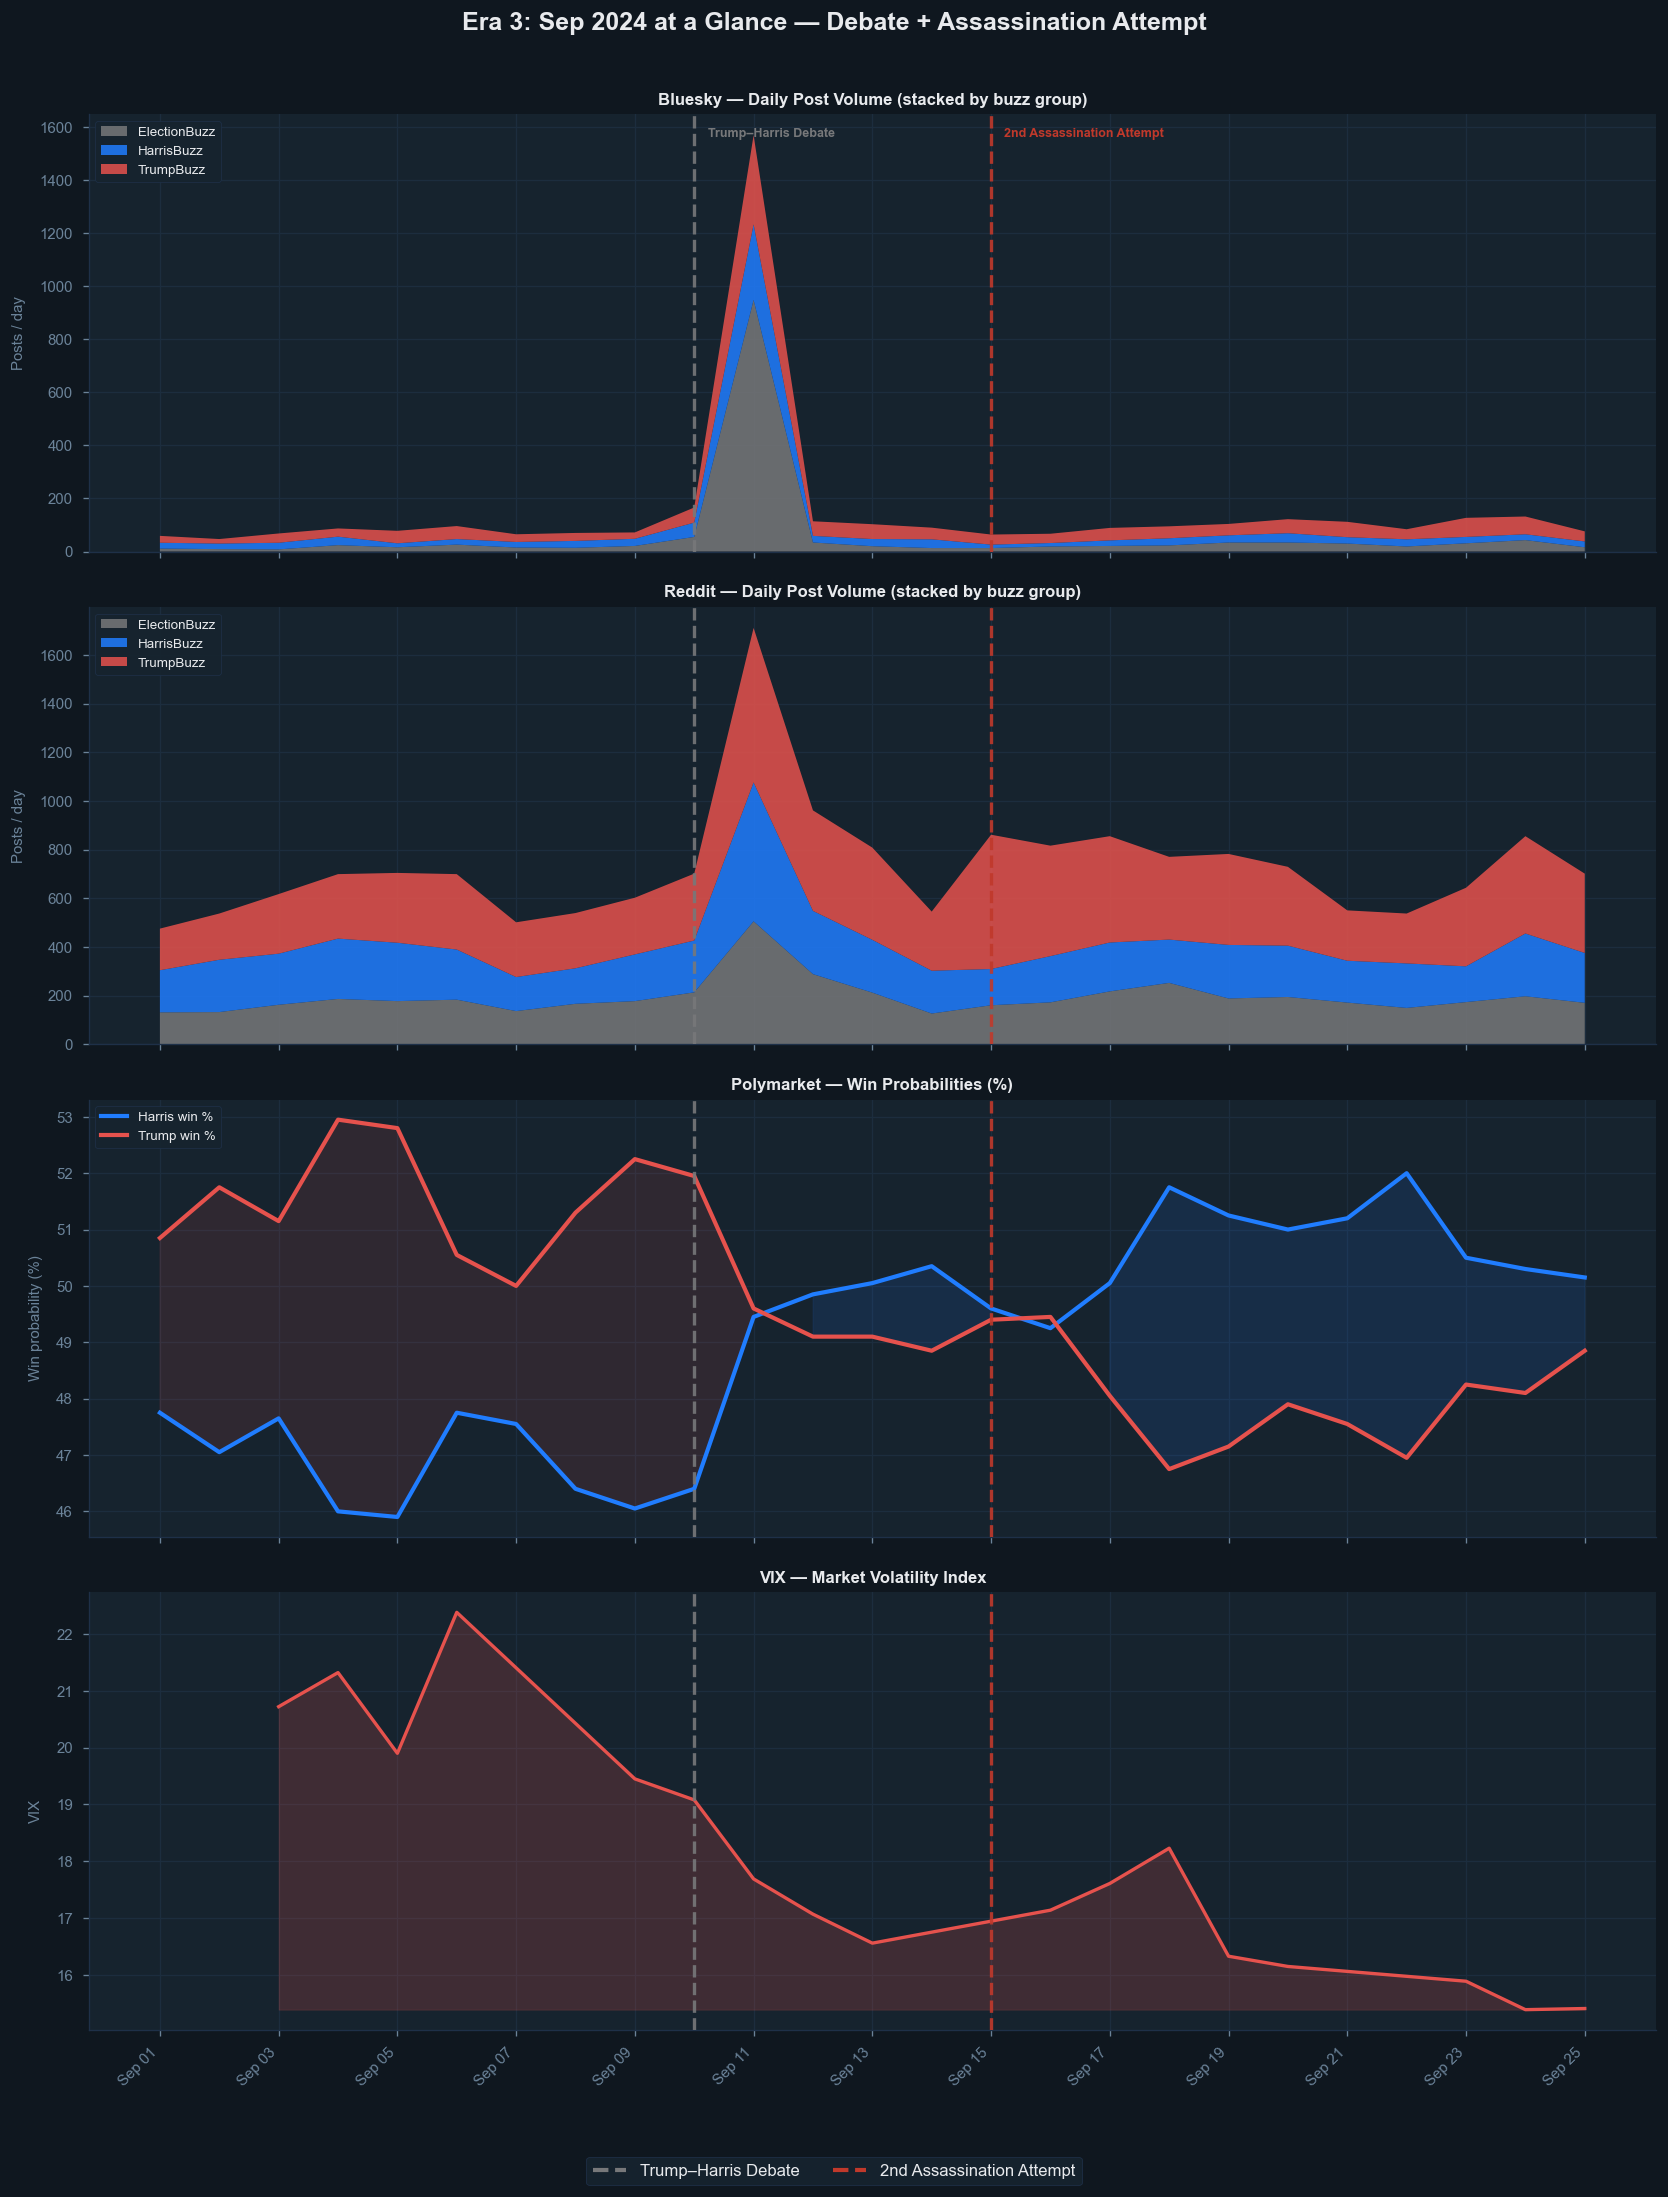

In [ ]:
date_range = pd.date_range(ERA_START, ERA_END)

# ── Daily Bluesky volume by buzz group ────────────────────────────────────────
bsky_era   = bsky[(bsky['date'] >= ERA_START) & (bsky['date'] <= ERA_END)]
bsky_daily = (bsky_era.groupby(['date', 'buzz_group'])
              .size().unstack(fill_value=0)
              .reindex(date_range, fill_value=0))
for c in BUZZ_ORDER:
    if c not in bsky_daily.columns: bsky_daily[c] = 0

# ── Daily Reddit posts volume by buzz group ───────────────────────────────────
reddit_era   = reddit[(reddit['date'] >= ERA_START) & (reddit['date'] <= ERA_END)]
reddit_daily = (reddit_era.groupby(['date', 'buzz_group'])
                .size().unstack(fill_value=0)
                .reindex(date_range, fill_value=0))
for c in BUZZ_ORDER:
    if c not in reddit_daily.columns: reddit_daily[c] = 0

poly_era   = poly[(poly['date']   >= ERA_START) & (poly['date']   <= ERA_END)]
mkt_era    = market[(market['Date'] >= ERA_START) & (market['Date'] <= ERA_END)]

# ── Figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(4, 1, figsize=(14, 18), sharex=True)
fig.patch.set_facecolor(BG_DARK)
fig.suptitle('Era 3: Sep 2024 at a Glance — Debate + Assassination Attempt',
             color=TEXT_PRIMARY, fontsize=15, fontweight='bold', y=1.01)

titles = ['Bluesky — Daily Post Volume (stacked by buzz group)',
          'Reddit — Daily Post Volume (stacked by buzz group)',
          'Polymarket — Win Probabilities (%)',
          'VIX — Market Volatility Index']

for ax, title in zip(axes, titles):
    ax.set_facecolor(BG_PANEL)
    for spine in ax.spines.values(): spine.set_edgecolor(SPINE_COLOR)
    ax.tick_params(colors=TEXT_MUTED)
    ax.set_title(title, color=TEXT_PRIMARY, fontsize=10, fontweight='bold', pad=6)

# Panel 1 — Bluesky
axes[0].stackplot(bsky_daily.index,
                  bsky_daily['ElectionBuzz'],
                  bsky_daily['HarrisBuzz'],
                  bsky_daily['TrumpBuzz'],
                  labels=['ElectionBuzz', 'HarrisBuzz', 'TrumpBuzz'],
                  colors=[NEUTRAL, DEMOCRAT, REPUBLICAN], alpha=0.85)
axes[0].set_ylabel('Posts / day', color=TEXT_MUTED, fontsize=9)
axes[0].legend(loc='upper left', facecolor=BG_PANEL, edgecolor=SPINE_COLOR,
               labelcolor=TEXT_PRIMARY, fontsize=8)

# Panel 2 — Reddit
axes[1].stackplot(reddit_daily.index,
                  reddit_daily['ElectionBuzz'],
                  reddit_daily['HarrisBuzz'],
                  reddit_daily['TrumpBuzz'],
                  labels=['ElectionBuzz', 'HarrisBuzz', 'TrumpBuzz'],
                  colors=[NEUTRAL, DEMOCRAT, REPUBLICAN], alpha=0.85)
axes[1].set_ylabel('Posts / day', color=TEXT_MUTED, fontsize=9)
axes[1].legend(loc='upper left', facecolor=BG_PANEL, edgecolor=SPINE_COLOR,
               labelcolor=TEXT_PRIMARY, fontsize=8)

# Panel 3 — Polymarket
axes[2].plot(poly_era['date'], poly_era['harris_pct'],
             color=DEMOCRAT, linewidth=2.5, label='Harris win %')
axes[2].plot(poly_era['date'], poly_era['trump_pct'],
             color=REPUBLICAN, linewidth=2.5, label='Trump win %')
axes[2].fill_between(poly_era['date'], poly_era['harris_pct'], poly_era['trump_pct'],
                     where=(poly_era['harris_pct'].values >= poly_era['trump_pct'].values),
                     color=DEMOCRAT, alpha=0.12)
axes[2].fill_between(poly_era['date'], poly_era['harris_pct'], poly_era['trump_pct'],
                     where=(poly_era['harris_pct'].values < poly_era['trump_pct'].values),
                     color=REPUBLICAN, alpha=0.12)
axes[2].set_ylabel('Win probability (%)', color=TEXT_MUTED, fontsize=9)
axes[2].legend(loc='upper left', facecolor=BG_PANEL, edgecolor=SPINE_COLOR,
               labelcolor=TEXT_PRIMARY, fontsize=8)

# Panel 4 — VIX
axes[3].plot(mkt_era['Date'], mkt_era['VIX'], color=PALETTE[1], linewidth=2)
axes[3].fill_between(mkt_era['Date'], mkt_era['VIX'], mkt_era['VIX'].min(),
                     color=PALETTE[1], alpha=0.20)
axes[3].set_ylabel('VIX', color=TEXT_MUTED, fontsize=9)

# Event lines on all panels
for ax in axes:
    for lbl, date, color in ERA_EVENTS:
        ax.axvline(pd.Timestamp(date), color=color, linestyle='--', linewidth=2, alpha=0.9, zorder=5)
    ax.grid(axis='y', color='#1c2d3e', linewidth=0.8)
    ax.set_axisbelow(True)

# Annotate event names on top panel only
for lbl, date, color in ERA_EVENTS:
    axes[0].annotate(lbl, xy=(pd.Timestamp(date), axes[0].get_ylim()[1]),
                     xytext=(8, -8), textcoords='offset points',
                     color=color, fontsize=7.5, fontweight='bold',
                     va='top', annotation_clip=False)

axes[3].xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
axes[3].xaxis.set_major_locator(mdates.DayLocator(interval=2))
plt.setp(axes[3].get_xticklabels(), rotation=45, ha='right', color=TEXT_MUTED)

# Shared event legend at bottom
fig.legend(handles=era_legend_handles(), loc='lower center',
           bbox_to_anchor=(0.5, 0.0), ncol=2,
           facecolor=BG_PANEL, edgecolor=SPINE_COLOR,
           labelcolor=TEXT_PRIMARY, fontsize=10, framealpha=0.95)
plt.tight_layout(rect=[0, 0.04, 1, 1], h_pad=1.5)
plt.show()

**Interpretation.** The four panels reveal two events with very different fingerprints across data sources.

The **debate (Sep 10)** produced a clear volume spike on Bluesky and Reddit. The composition shift is the most striking signal: *both* TrumpBuzz and HarrisBuzz contracted sharply (−15 pp and −17 pp respectively) while ElectionBuzz exploded +32 pp. The debate pulled users out of partisan silos and into a shared general-election conversation — not a Harris surge, but a temporary dissolution of partisan clustering. On Polymarket, Harris’s win probability jumped meaningfully: from 46.4% on debate day to 49.45% by the next morning (+3 pp), briefly putting her ahead of Trump for the first time. Financial markets interpreted the debate as *uncertainty reduction*: the VIX fell steadily after Sep 10, not spiked.

The **assassination attempt (Sep 15)** produced a second social media spike, but one that was almost entirely Trump-focused. Unlike the debate, it barely altered the Bluesky buzz-group composition (all three groups shifted by less than 5 pp). The VIX ticked up modestly after Sep 15 — a smaller and shorter-lived response than the first assassination attempt in July.

The contrast between the two events is asymmetric: the debate was a *shared* political moment that temporarily united conversation streams; the assassination attempt was a *Trump-centred* event with limited cross-partisan pull.

---
## 2 · What People Talked About — TF-IDF Term Shifts (Bluesky & Reddit)

For each event, the ±3-day pre/post windows are compared using TF-IDF to surface vocabulary that newly dominated after the event. Highlighted bars (coloured) indicate terms that were *not* in the pre-window top-15 — i.e. genuinely new post-event vocabulary. The 2×2 grid shows the same analysis side-by-side for **Bluesky** and **Reddit**, revealing platform-specific differences in how each audience processed these events.

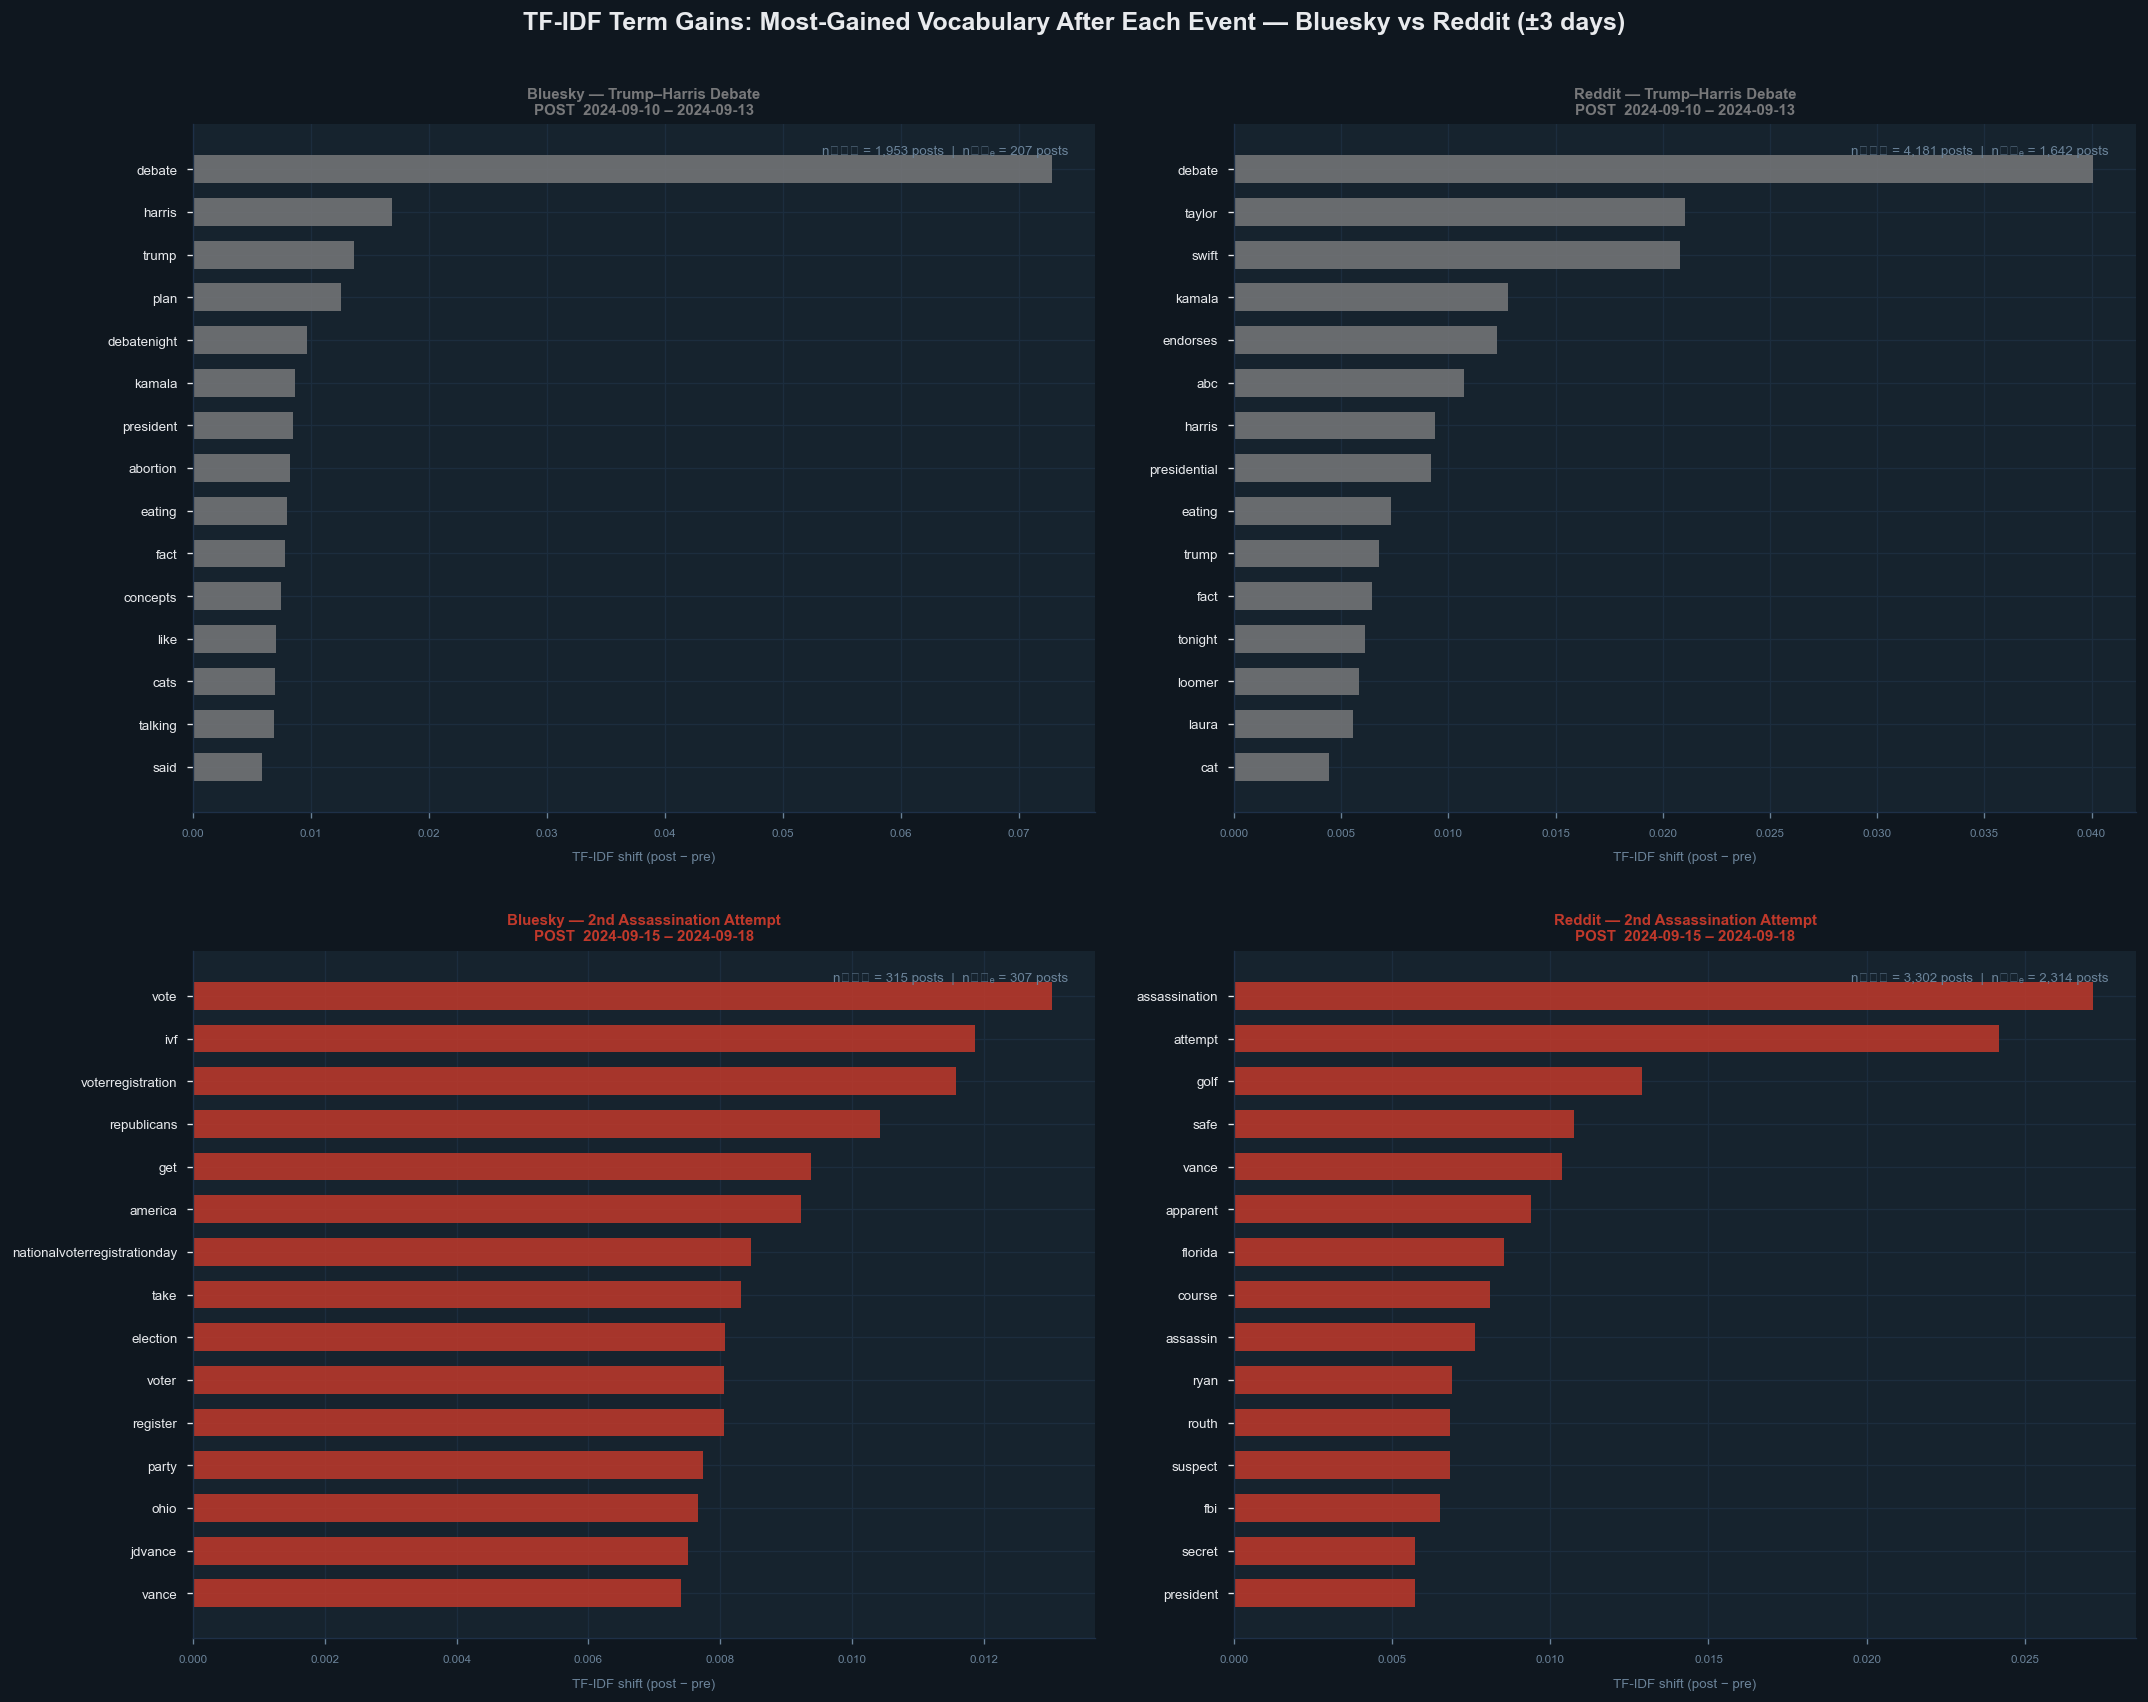

In [ ]:
TFIDF_EVENTS = [
    {'label': 'Trump–Harris Debate',       'date': DEBATE,   'color': NEUTRAL},
    {'label': '2nd Assassination Attempt', 'date': ATTEMPT2, 'color': '#c0392b'},
]
PLATFORMS = [
    ('Bluesky', bsky,   'text_clean', 'date'),
    ('Reddit',  reddit, 'text_clean', 'date'),
]

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.patch.set_facecolor(BG_DARK)
fig.suptitle('TF-IDF Term Gains: Most-Gained Vocabulary After Each Event — Bluesky vs Reddit (±3 days)',
             color=TEXT_PRIMARY, fontsize=15, fontweight='bold', y=1.01)

for row, ev in enumerate(TFIDF_EVENTS):
    for col, (plat_name, df, text_col, date_col) in enumerate(PLATFORMS):
        ax = axes[row][col]
        ax.set_facecolor(BG_PANEL)
        for spine in ax.spines.values(): spine.set_edgecolor(SPINE_COLOR)

        # pre: WINDOW days before event; post: event day + WINDOW days after
        pre  = df[(df[date_col] >= ev['date'] - pd.Timedelta(days=WINDOW)) &
                  (df[date_col] <  ev['date'])]
        post = df[(df[date_col] >= ev['date']) &
                  (df[date_col] <= ev['date'] + pd.Timedelta(days=WINDOW))]

        gained = top_tfidf_gained(pre[text_col].tolist(), post[text_col].tolist())

        if gained.empty:
            ax.text(0.5, 0.5, 'not enough data', ha='center', va='center',
                    color=TEXT_MUTED, transform=ax.transAxes)
        else:
            terms  = gained.index[::-1]
            values = gained.values[::-1]
            ax.barh(terms, values, color=ev['color'], edgecolor='none', height=0.65, alpha=0.85)

        date_str = f'{ev["date"].date()} – {(ev["date"] + pd.Timedelta(days=WINDOW)).date()}'
        ax.set_title(
            f'{plat_name} — {ev["label"]}\nPOST  {date_str}',
            color=ev['color'], fontsize=9, fontweight='bold', pad=6
        )
        ax.set_xlabel('TF-IDF shift (post − pre)', color=TEXT_MUTED, fontsize=8)
        ax.tick_params(axis='y', labelsize=8, colors=TEXT_PRIMARY)
        ax.tick_params(axis='x', labelsize=7, colors=TEXT_MUTED)
        ax.grid(axis='x', color='#1c2d3e', linewidth=0.8)
        ax.set_axisbelow(True)
        ax.annotate(f'nₚₕₜ = {len(post):,} posts  |  nₚ⬿ₑ = {len(pre):,} posts',
                    xy=(0.97, 0.97), xycoords='axes fraction',
                    ha='right', va='top', fontsize=8, color=TEXT_MUTED)

plt.tight_layout(h_pad=3, w_pad=2.5)
plt.show()

**Interpretation.** The bars show which vocabulary *gained most* in the post-event window relative to the pre-event baseline (TF-IDF shift: post − pre). This surfaces event-specific language rather than high-frequency political terms that dominate any window.

**Debate (Sep 10) — Bluesky:** The biggest gainers are *debate*, *harris*, *debatenight*, *plan*, *kamala*, *fact*, *abortion* — and three terms that directly reference Trump's two most-mocked moments of the night: *eating*, *cats*, and *concepts*. Trump's claim that Haitian immigrants were “eating the dogs, eating the cats” in Springfield, Ohio, and his healthcare non-answer (“concepts of a plan”) became instant viral content on Bluesky, making it into the top 15 most-gained terms despite competing with 'debate' and 'harris'. Harris-related terms dominate the upper half, confirming the debate moved the *Harris* conversation more than Trump's in volume terms.

**Debate (Sep 10) — Reddit:** The same viral Trump moments appear (*eating*, *cat*), but the Reddit-specific story is **Taylor Swift**. *Taylor*, *swift*, *endorses* are among the top gained terms — Swift announced her endorsement of Kamala Harris within hours of the debate ending, generating massive Reddit discussion that co-dominated with the debate itself. *abc* (the broadcast network) also newly entered — Reddit users discussed the debate's production context. Reddit combined three stories in one news cycle: the debate, the viral Trump moments, and the Swift endorsement.

**2nd Assassination Attempt (Sep 15) — Bluesky:** The dominant gained terms are *nationalvoterregistrationday*, *voterregistration*, *register*, *voter*, *vote*, *ivf*. September 15 was National Voter Registration Day — an annual civic event that flooded Bluesky with get-out-the-vote content and almost entirely displaced assassination-attempt discourse. The attack is nearly invisible in Bluesky's vocabulary.

**2nd Assassination Attempt (Sep 15) — Reddit:** The opposite picture: genuine security vocabulary dominates — *assassination*, *attempt*, *golf*, *florida*, *assassin*, *routh* (Ryan Wesley Routh, the apprehended suspect), *fbi*, *secret* (Secret Service). Reddit processed the event factually and immediately. The pre-window (*debate*, *kamala*, *harris*) confirms the fast news cycle turnover from debate to political violence in five days.

**Cross-platform conclusion:** Bluesky reflects an audience that amplifies memes (eating/cats/concepts), civic mobilisation (NVRD), and evaluative debate framing. Reddit reflects a broader news-consuming public that adds celebrity news (Taylor Swift) and processes actual events (assassination attempt vocabulary). Combining both platforms gives a fuller picture than either alone.

### 2b · Slide version — Debate term gains (Bluesky vs Reddit)

Presentation: top 8 gained terms only, viral/surprising terms highlighted, x-axis values removed.

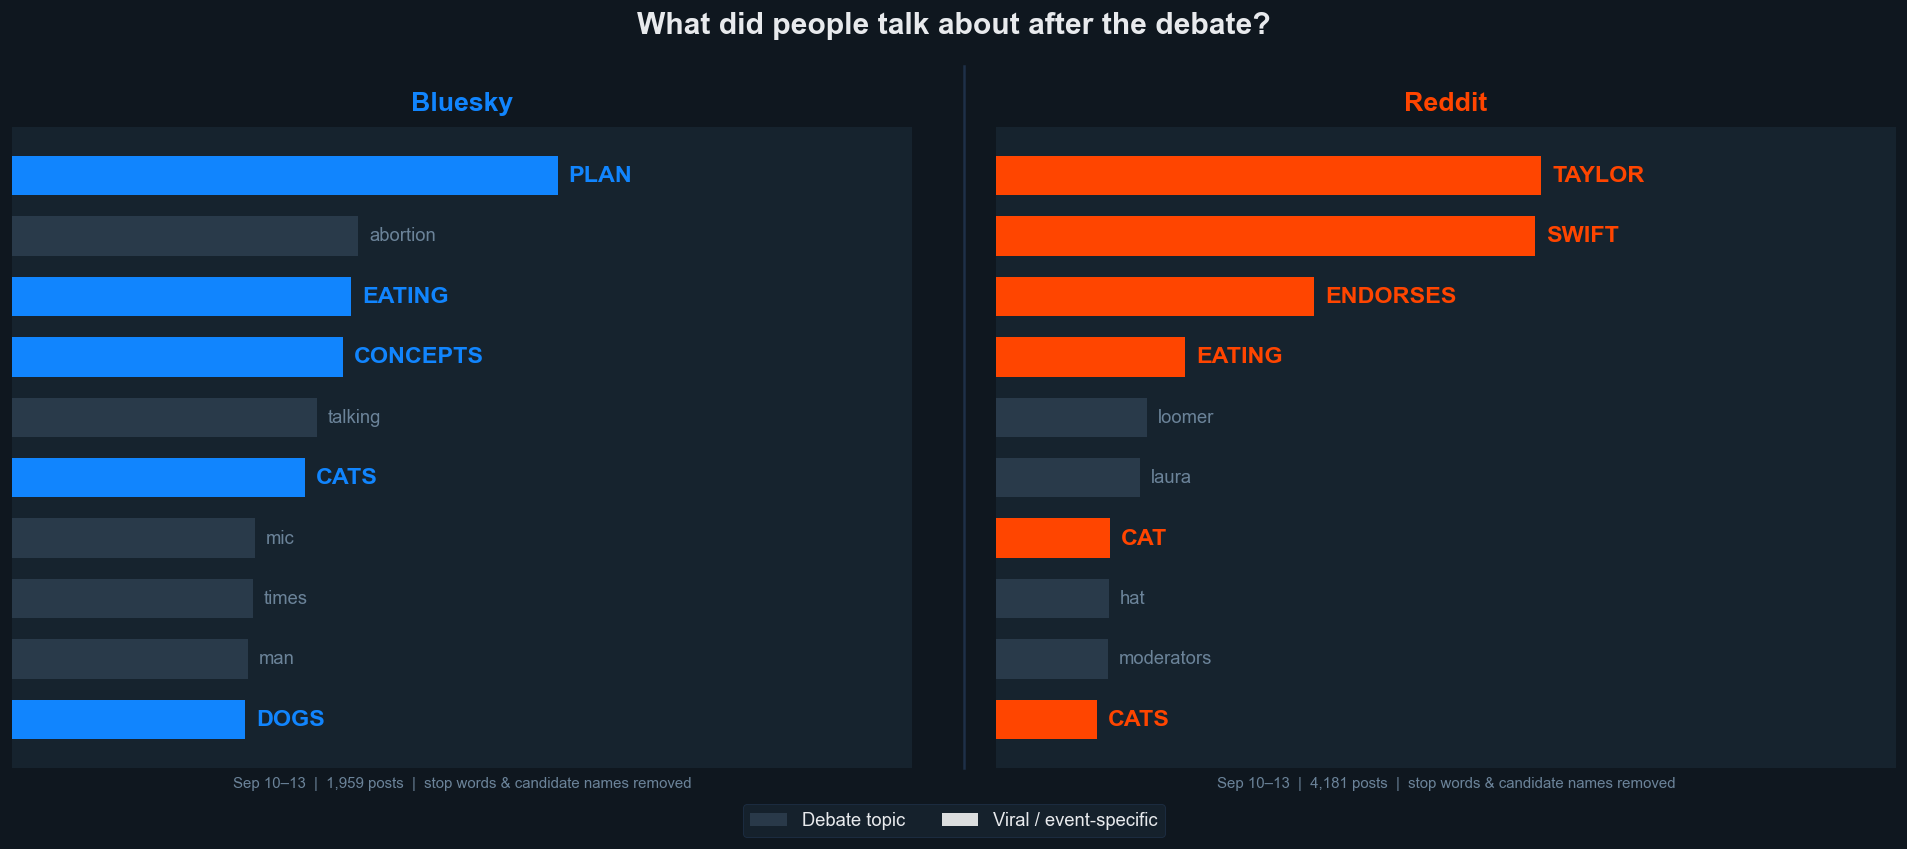

In [3]:
# ── Slide version: Debate TF-IDF — Bluesky vs Reddit (presentation-ready) ──────
# Candidate names + generic stopwords removed so surprising terms stand out

VIRAL_BLUESKY = {'plan','eating', 'cats', 'concepts', 'dogs', 'pets'}
VIRAL_REDDIT  = {'taylor', 'swift', 'endorses', 'eating', 'cat', 'cats'}
N_TERMS = 10
SLIDE_STOP = {
    'debate','debatenight','presidentialdebate','harris','kamala','trump','donald',
    'president','presidential','like','people','said','would','tonight','today','time',
    'abc','maga','election','fact','just','got','going','political','vote','voting',
    'campaign','candidate','america','american','republican','democrat','party','news',
}

pre_b  = bsky[(bsky['date'] >= DEBATE - pd.Timedelta(days=WINDOW)) & (bsky['date'] < DEBATE)]
post_b = bsky[(bsky['date'] >= DEBATE) & (bsky['date'] <= DEBATE + pd.Timedelta(days=WINDOW))]
pre_r  = reddit[(reddit['date'] >= DEBATE - pd.Timedelta(days=WINDOW)) & (reddit['date'] < DEBATE)]
post_r = reddit[(reddit['date'] >= DEBATE) & (reddit['date'] <= DEBATE + pd.Timedelta(days=WINDOW))]

gained_b = top_tfidf_gained(pre_b['text_clean'].tolist(), post_b['text_clean'].tolist(), n=N_TERMS * 4)
gained_r = top_tfidf_gained(pre_r['text_clean'].tolist(), post_r['text_clean'].tolist(), n=N_TERMS * 4)
gained_b = gained_b[~gained_b.index.isin(SLIDE_STOP)].head(N_TERMS)
gained_r = gained_r[~gained_r.index.isin(SLIDE_STOP)].head(N_TERMS)

BLUESKY_BLUE = '#1185fe'
REDDIT_ORG   = '#ff4500'

fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(16, 6.5))
fig.patch.set_facecolor(BG_DARK)
fig.suptitle('What did people talk about after the debate?',
             color=TEXT_PRIMARY, fontsize=18, fontweight='bold', y=1.02)

slide_data = [
    (ax_l, gained_b, VIRAL_BLUESKY, BLUESKY_BLUE, 'Bluesky', len(post_b)),
    (ax_r, gained_r, VIRAL_REDDIT,  REDDIT_ORG,   'Reddit',  len(post_r)),
]
for ax, gained, viral_set, base_color, plat_label, n_post in slide_data:
    ax.set_facecolor(BG_PANEL)
    terms  = gained.index[::-1]
    values = gained.values[::-1]
    max_v  = values.max() if len(values) else 1
    bars = ax.barh(range(len(terms)), values,
                   color=[base_color if t in viral_set else '#3d5166' for t in terms],
                   edgecolor='none', height=0.65)
    for bar, t in zip(bars, terms): bar.set_alpha(1.0 if t in viral_set else 0.5)
    for i, (t, v) in enumerate(zip(terms, values)):
        ax.text(v + max_v * 0.02, i, t.upper() if t in viral_set else t,
                va='center', ha='left',
                fontsize=14 if t in viral_set else 11,
                fontweight='bold' if t in viral_set else 'normal',
                color=base_color if t in viral_set else TEXT_MUTED)
    ax.set_yticks([]); ax.set_xticks([])
    ax.set_xlim(0, max_v * 1.65)
    for s in ['bottom', 'left', 'top', 'right']: ax.spines[s].set_visible(False)
    ax.set_title(plat_label, color=base_color, fontsize=16, fontweight='bold', pad=10)
    ax.annotate(f'Sep 10–13  |  {n_post:,} posts  |  stop words & candidate names removed',
                xy=(0.5, -0.03), xycoords='axes fraction',
                ha='center', fontsize=9, color=TEXT_MUTED)

fig.add_artist(plt.Line2D([0.505, 0.505], [0.05, 0.95],
                           transform=fig.transFigure, color=SPINE_COLOR, linewidth=1.5))
from matplotlib.patches import Patch as _Patch
fig.legend(handles=[
    _Patch(facecolor='#3d5166', alpha=0.5,  label='Debate topic'),
    _Patch(facecolor='white',   alpha=0.85, label='Viral / event-specific'),
], loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.05), fontsize=11,
           facecolor=BG_PANEL, edgecolor=SPINE_COLOR, labelcolor=TEXT_PRIMARY)

plt.tight_layout(w_pad=5)
plt.show()


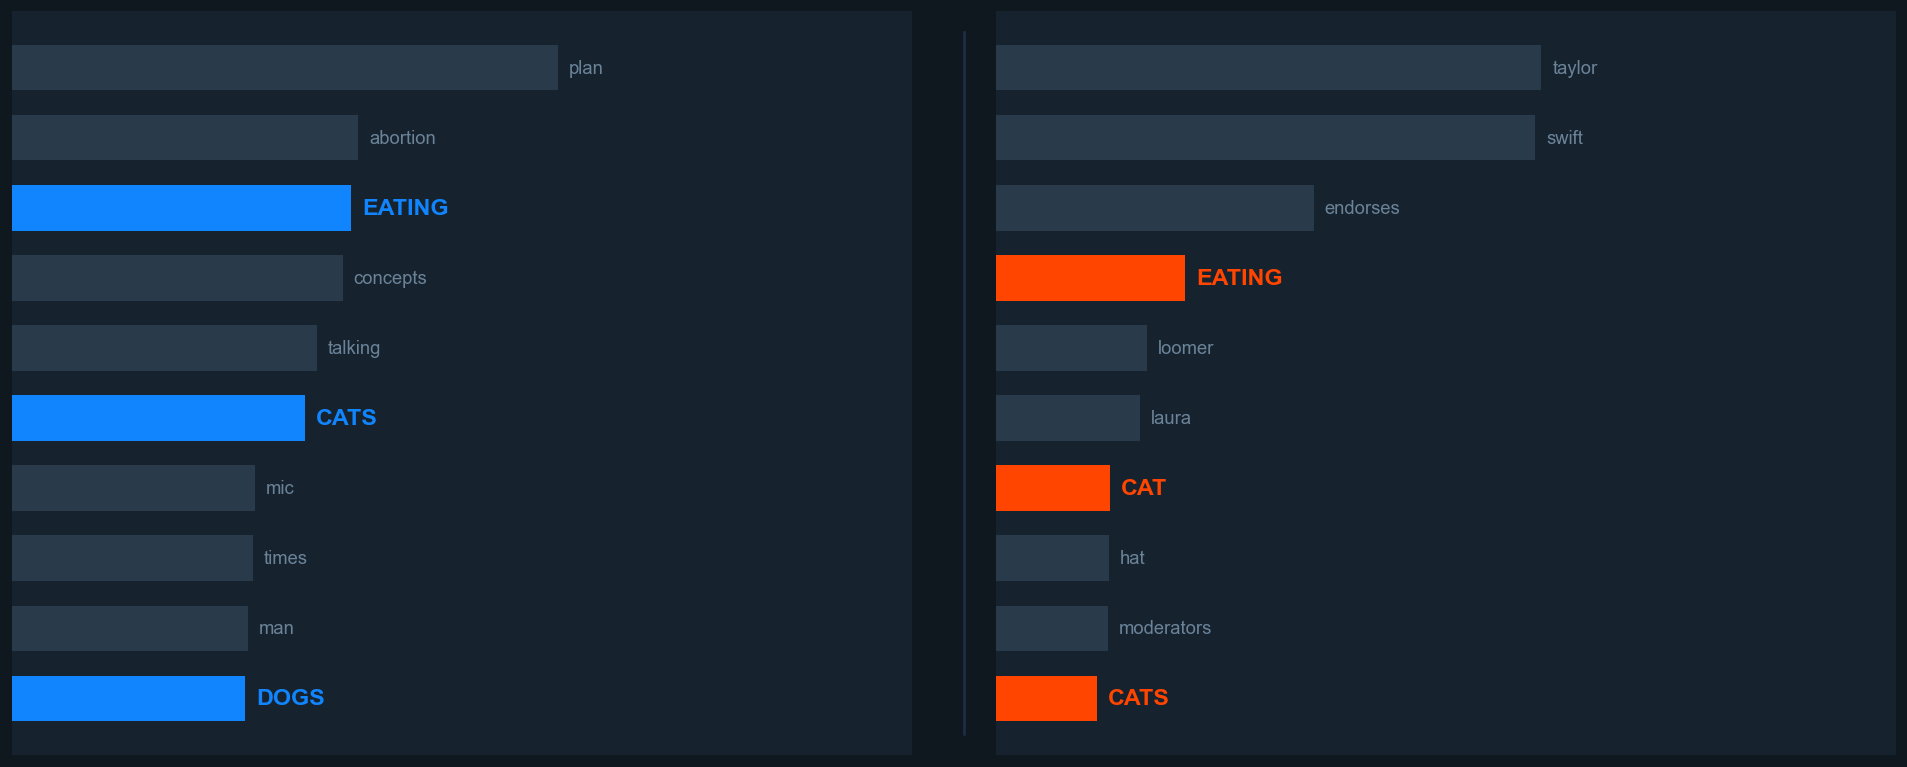

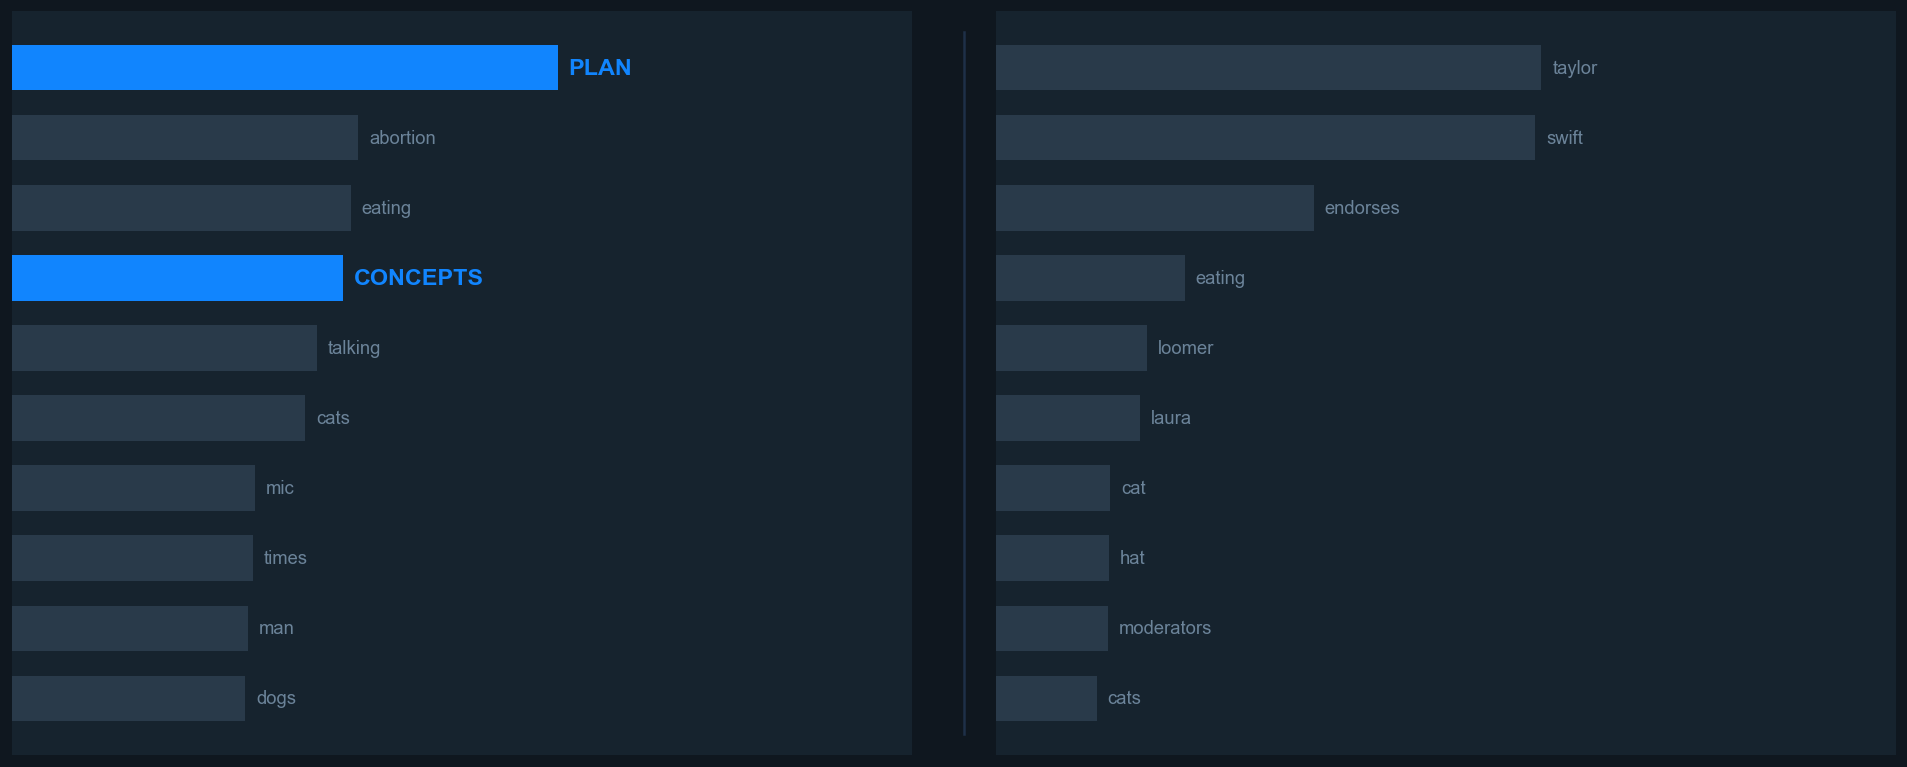

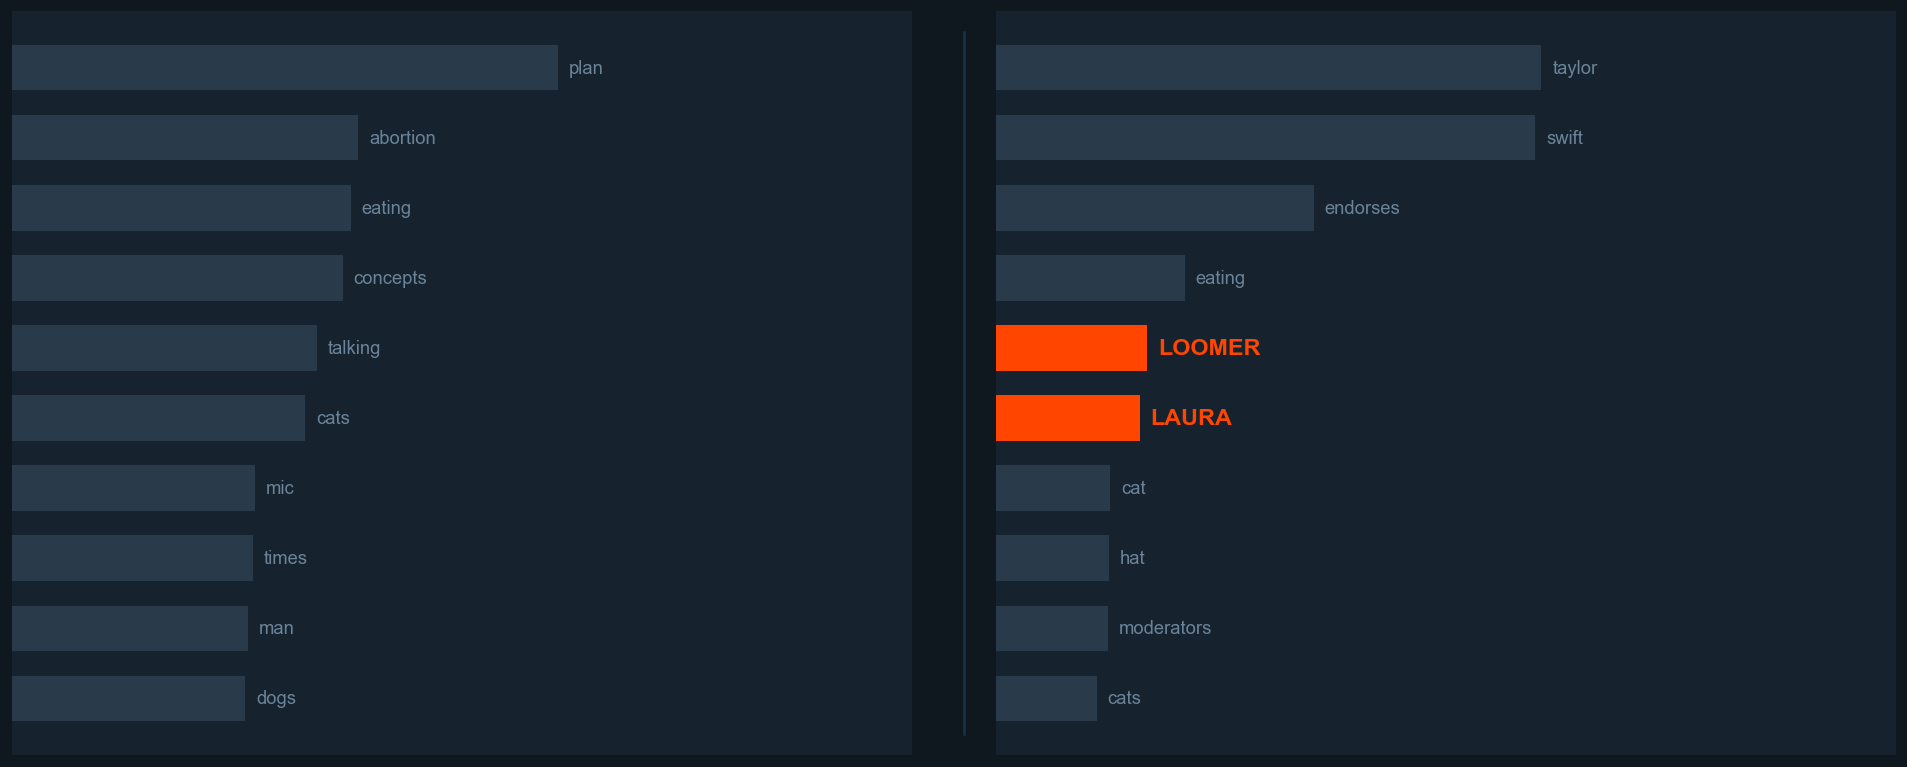

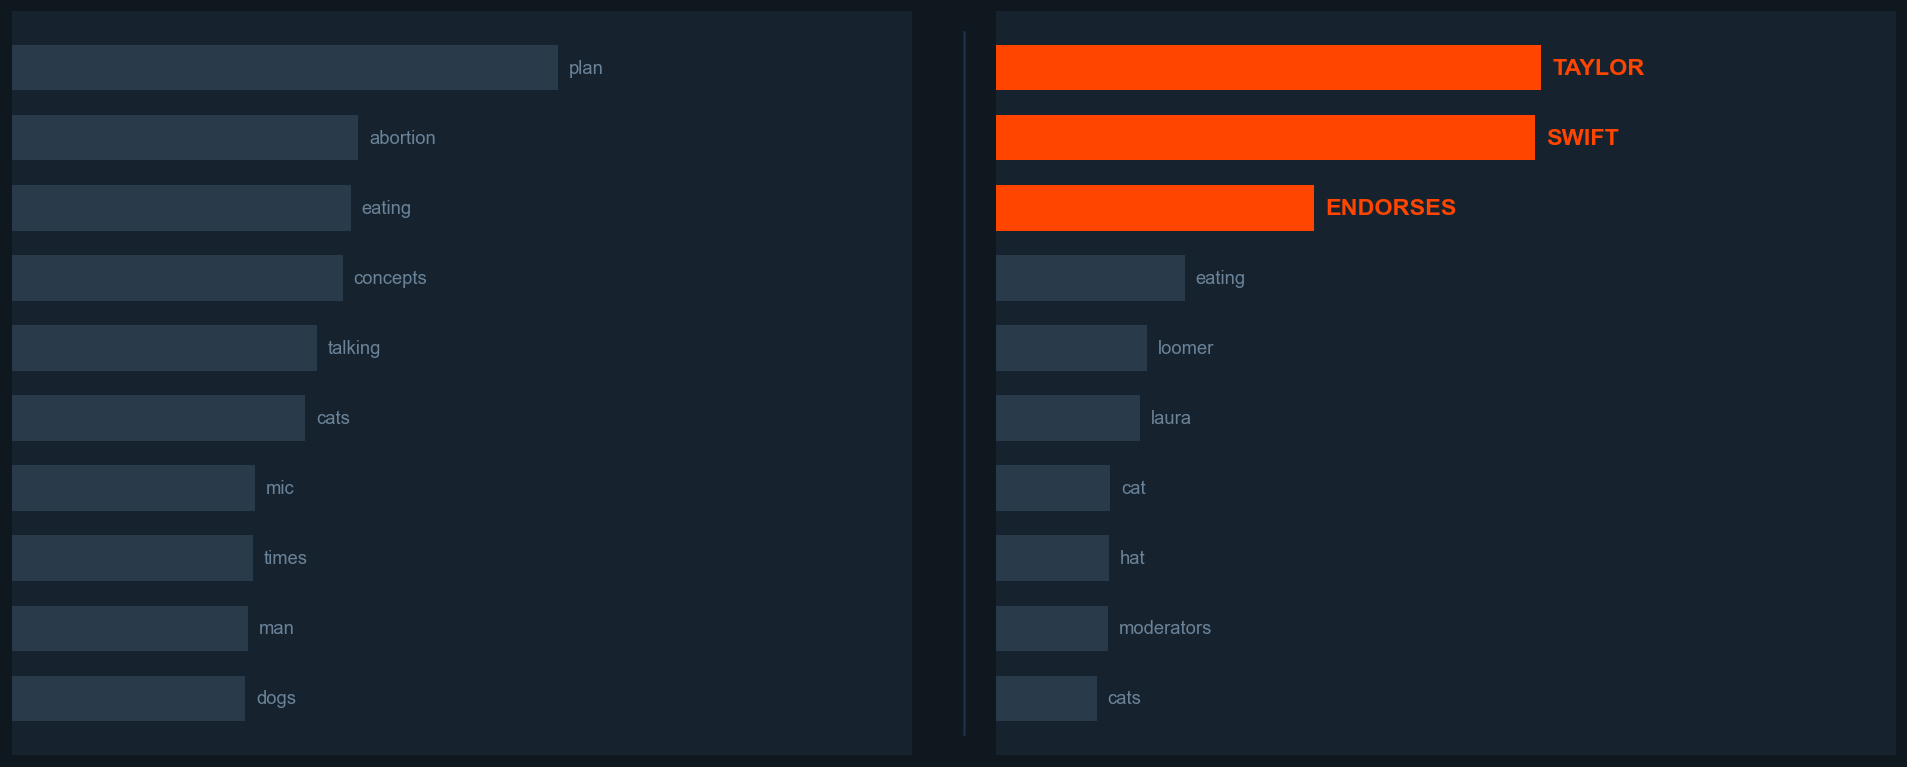

In [15]:
# Figure 2b variants: 4 quote lenses
DEBATE_QUOTE_CONFIGS = [
    {
        'title':   'Eating the dogs / eating the cats',
        'viral_b': {'eating', 'dogs', 'cats', 'pets', 'people'},
        'viral_r': {'eating', 'dogs', 'cats', 'cat', 'pets'},
    },
    {
        'title':   'Concepts of a plan',
        'viral_b': {'plan', 'concepts', 'healthcare'},
        'viral_r': {'plan', 'concepts', 'healthcare'},
    },
    {
        'title':   'Debate moderators (Laura / ABC)',
        'viral_b': {'laura', 'loomer'},
        'viral_r': {'laura', 'loomer'},
    },
    {
        'title':   'Taylor Swift endorsement',
        'viral_b': {'taylor', 'swift', 'endorses', 'endorsement', 'vote'},
        'viral_r': {'taylor', 'swift', 'endorses', 'endorsement', 'vote'},
    },
]

def _plot_debate_variant(gained_b, gained_r, pre_b, post_b, pre_r, post_r, cfg):
    fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(16, 6.5))
    fig.patch.set_facecolor(BG_DARK)

    slide_data = [
        (ax_l, gained_b, cfg['viral_b'], BLUESKY_BLUE),
        (ax_r, gained_r, cfg['viral_r'], REDDIT_ORG),
    ]
    for ax, gained, viral_set, base_color in slide_data:
        ax.set_facecolor(BG_PANEL)
        terms  = gained.index[::-1]
        values = gained.values[::-1]
        max_v  = values.max() if len(values) else 1
        bars = ax.barh(range(len(terms)), values,
                       color=[base_color if t in viral_set else '#3d5166' for t in terms],
                       edgecolor='none', height=0.65)
        for bar, t in zip(bars, terms):
            bar.set_alpha(1.0 if t in viral_set else 0.5)
        for i, (t, v) in enumerate(zip(terms, values)):
            ax.text(v + max_v * 0.02, i,
                    t.upper() if t in viral_set else t,
                    va='center', ha='left',
                    fontsize=14 if t in viral_set else 11,
                    fontweight='bold' if t in viral_set else 'normal',
                    color=base_color if t in viral_set else TEXT_MUTED)
        ax.set_yticks([]); ax.set_xticks([])
        ax.set_xlim(0, max_v * 1.65)
        for s in ['bottom', 'left', 'top', 'right']: ax.spines[s].set_visible(False)

    fig.add_artist(plt.Line2D([0.505, 0.505], [0.05, 0.95],
                               transform=fig.transFigure, color=SPINE_COLOR, linewidth=1.5))
    plt.tight_layout(w_pad=5)
    plt.show()

for _cfg in DEBATE_QUOTE_CONFIGS:
    _plot_debate_variant(gained_b, gained_r, pre_b, post_b, pre_r, post_r, _cfg)


---
## 3 · Who Was Talking — Buzz-Group Composition Shift (Bluesky & Reddit)

Beyond *what* people talked about, *who* was talking shifted too. Posts are assigned to TrumpBuzz, HarrisBuzz, or ElectionBuzz based on the hashtag cluster (Bluesky) or subreddit (Reddit: r/trump + r/conservative + r/republican = TrumpBuzz; r/democrats + r/liberal = HarrisBuzz; r/politics + r/worldnews = ElectionBuzz). The 2×2 grid compares composition shifts across both platforms, revealing whether partisan communities mobilised differently on each platform.

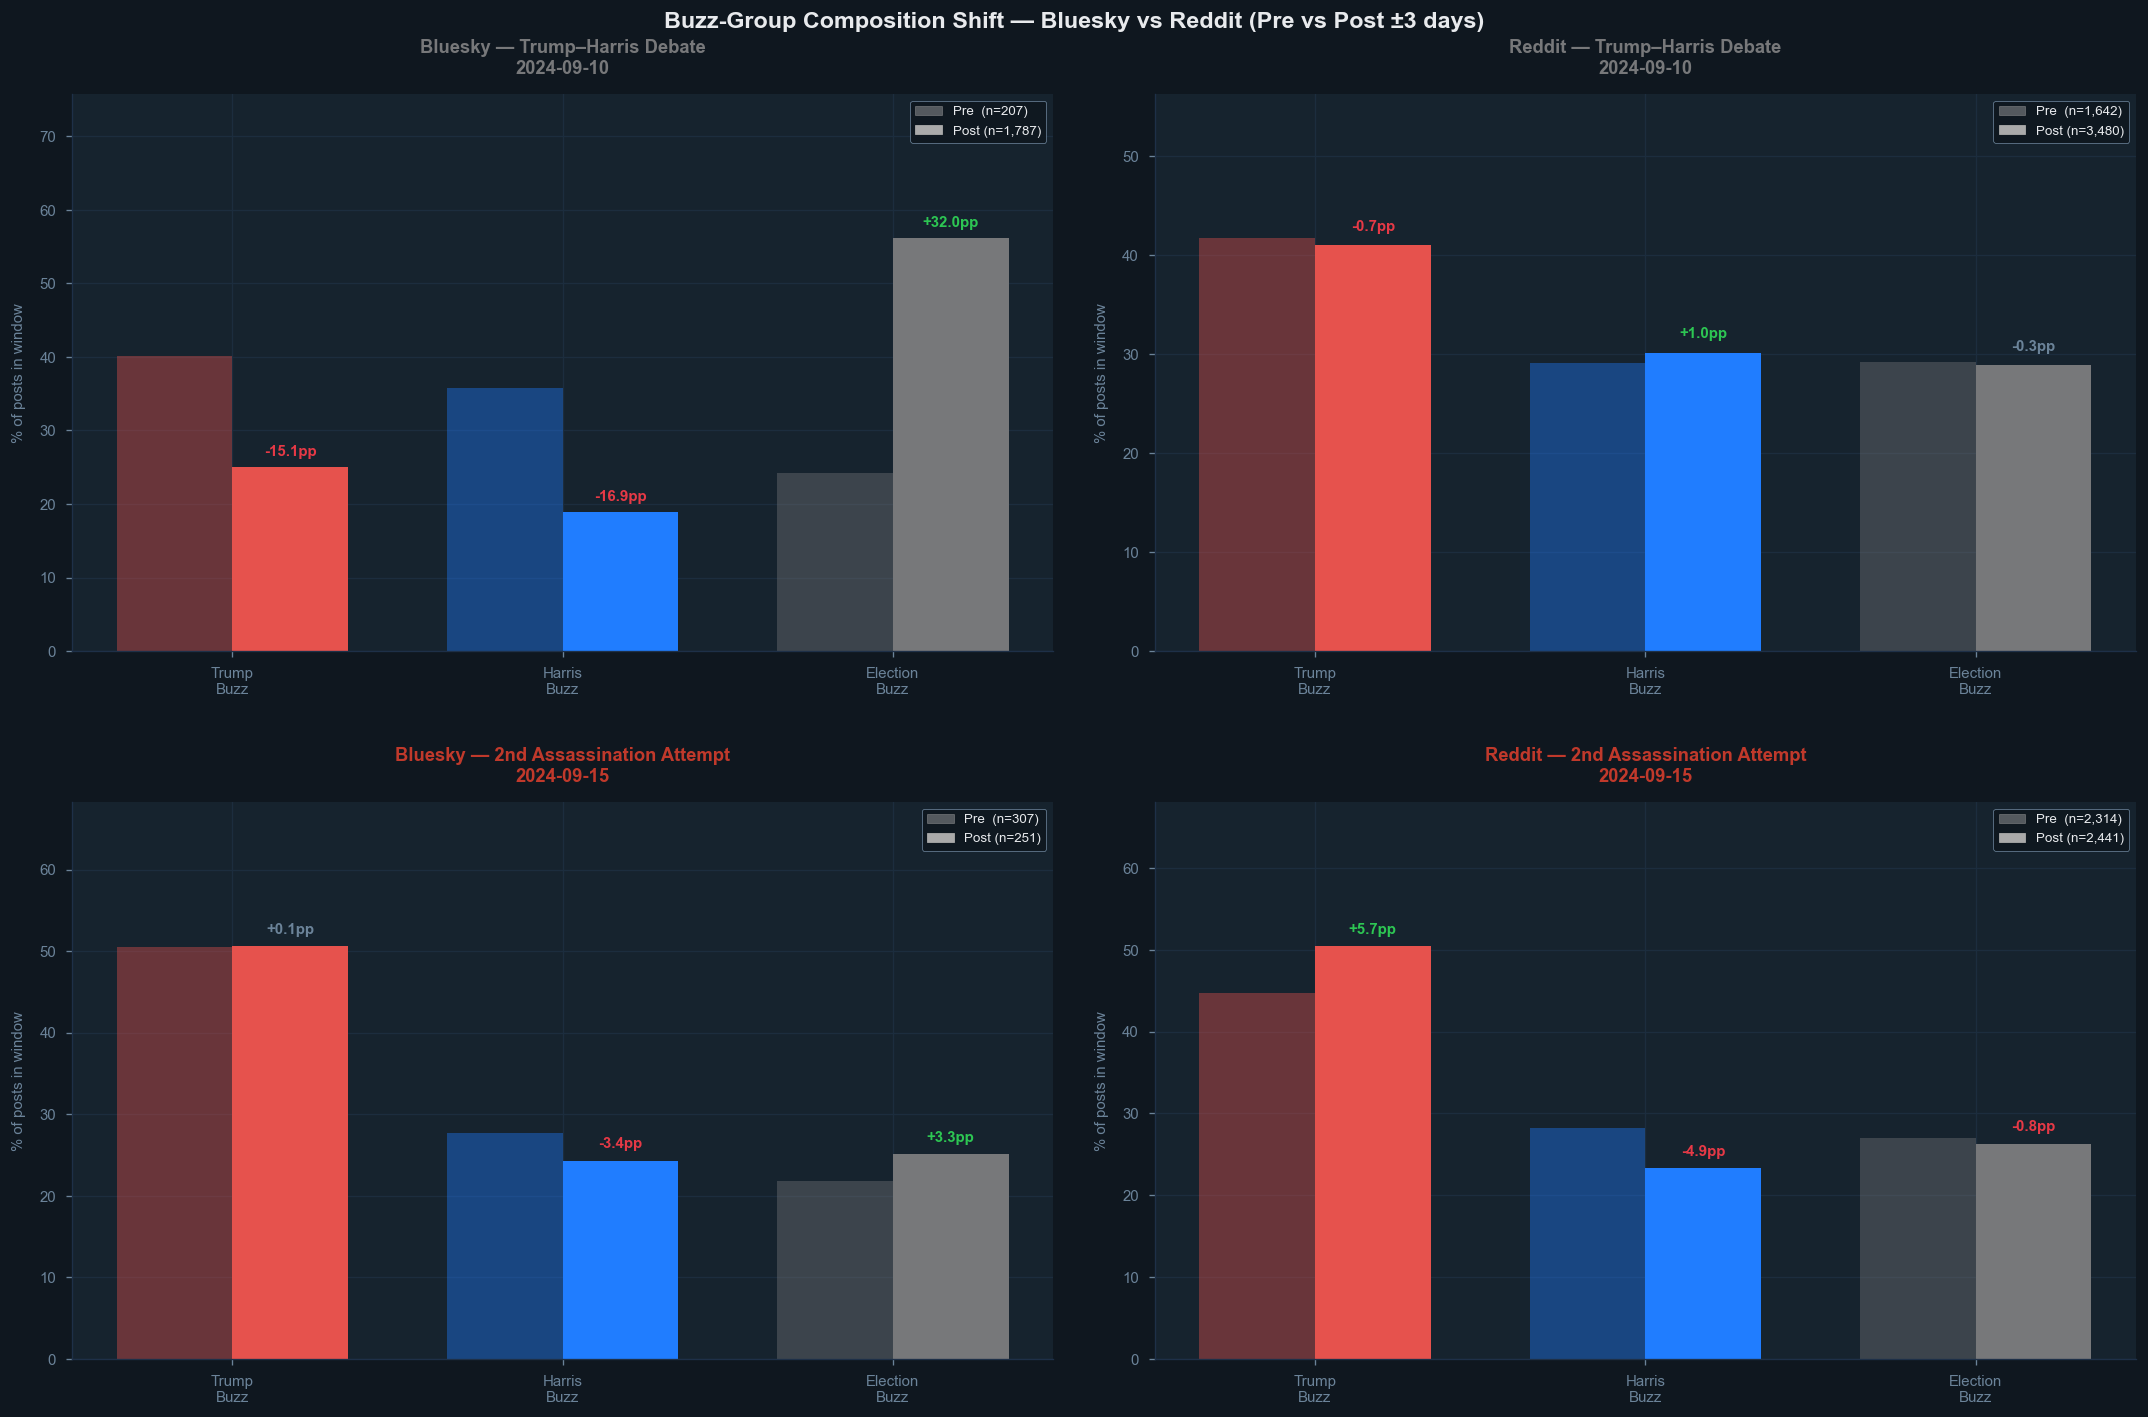

In [ ]:
EVENTS_MARK = {
    'debate':        [('2024-09-10', 'Debate', TEXT_MUTED)],
    'assassination': [('2024-09-15', '2nd Attempt', REPUBLICAN)],
}
PANEL_TITLES = {
    'debate':        'Daily coverage of "debate"',
    'assassination': 'Daily coverage of "assassination"',
}

EVENTS_INFO = [
    ('Trump–Harris Debate',       DEBATE,   NEUTRAL),
    ('2nd Assassination Attempt', ATTEMPT2, '#c0392b'),
]
PLATFORMS3 = [
    ('Bluesky', bsky,   'date'),
    ('Reddit',  reddit, 'date'),
]

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.patch.set_facecolor(BG_DARK)
fig.suptitle('Buzz-Group Composition Shift — Bluesky vs Reddit (Pre vs Post ±3 days)',
             color=TEXT_PRIMARY, fontsize=14, fontweight='bold')

for row, (ev_label, ev_date, ev_color) in enumerate(EVENTS_INFO):
    for col, (plat_name, df, date_col) in enumerate(PLATFORMS3):
        ax = axes[row][col]
        ax.set_facecolor(BG_PANEL)
        for spine in ax.spines.values(): spine.set_edgecolor(SPINE_COLOR)

        pre, post = get_window(df, date_col, ev_date)

        def buzz_pct(dff):
            vc = dff['buzz_group'].value_counts(normalize=True) * 100
            return {k: vc.get(k, 0) for k in BUZZ_ORDER}

        pre_pct  = buzz_pct(pre)
        post_pct = buzz_pct(post)

        x, w = np.arange(len(BUZZ_ORDER)), 0.35
        pre_vals  = [pre_pct[c]  for c in BUZZ_ORDER]
        post_vals = [post_pct[c] for c in BUZZ_ORDER]
        bar_colors = [BUZZ_COLORS[c] for c in BUZZ_ORDER]

        ax.bar(x - w/2, pre_vals,  w, color=bar_colors, alpha=0.40, edgecolor='none', label='Pre')
        ax.bar(x + w/2, post_vals, w, color=bar_colors, alpha=1.00, edgecolor='none', label='Post')

        for i, (pv, pov) in enumerate(zip(pre_vals, post_vals)):
            delta = pov - pv
            sign  = '+' if delta >= 0 else ''
            clr   = '#2dc653' if delta > 0.5 else ('#e63946' if delta < -0.5 else TEXT_MUTED)
            ax.text(i + w/2, pov + 1.2, f'{sign}{delta:.1f}pp',
                    ha='center', va='bottom', fontsize=9, color=clr, fontweight='bold')

        ax.set_xticks(x)
        ax.set_xticklabels(['Trump\nBuzz', 'Harris\nBuzz', 'Election\nBuzz'],
                           fontsize=9, color=TEXT_MUTED)
        ax.set_ylabel('% of posts in window', color=TEXT_MUTED, fontsize=9)
        ax.set_title(f'{plat_name} — {ev_label}\n{ev_date.date()}',
                     color=ev_color, fontsize=11, fontweight='bold')
        ax.tick_params(colors=TEXT_MUTED)
        ax.set_ylim(0, max(max(pre_vals), max(post_vals)) * 1.35)
        ax.grid(axis='y', color='#1c2d3e', linewidth=0.8)
        ax.set_axisbelow(True)

        pre_patch  = mpatches.Patch(color='#aaaaaa', alpha=0.45, label=f'Pre  (n={len(pre):,})')
        post_patch = mpatches.Patch(color='#aaaaaa', alpha=1.00, label=f'Post (n={len(post):,})')
        ax.legend(handles=[pre_patch, post_patch], fontsize=8, loc='upper right',
                  facecolor=BG_DARK, edgecolor=TEXT_MUTED, labelcolor=TEXT_PRIMARY)

plt.tight_layout(h_pad=3, w_pad=2.5)
plt.show()

**Interpretation.** The 2×2 grid reveals that Bluesky and Reddit mobilised in fundamentally different ways — the two platforms are not interchangeable proxies for public opinion.

**After the debate:**
- **Bluesky**: TrumpBuzz −15 pp, HarrisBuzz −17 pp, ElectionBuzz +32 pp. A dramatic convergence: both partisan communities contracted while general election conversation exploded. The debate dissolved Bluesky's partisan clustering.
- **Reddit**: Near-flat changes (−1 pp, +1 pp, 0 pp). Reddit's subreddit structure kept users in their communities. There was no cross-partisan surge — partisans stayed in r/trump and r/democrats and discussed the debate within their own spaces.

**After the assassination attempt:**
- **Bluesky**: Minimal movement: TrumpBuzz +0.1 pp, HarrisBuzz −3.4 pp, ElectionBuzz +3.3 pp. Consistent with the NVRD effect observed in Section 2 — civic-action content competed with the political violence story, suppressing partisan mobilisation.
- **Reddit**: Clear partisan surge: TrumpBuzz +5.7 pp (to 51%), HarrisBuzz −4.9 pp, ElectionBuzz −0.8 pp. An assassination attempt on the Republican candidate drove a significant influx of activity into Trump/conservative/Republican subreddits. Democratic communities went comparatively quiet.

**The key insight:** For the debate, Bluesky shows a *structural* realignment (partisan → general) while Reddit shows *stability*. For the assassination attempt, Bluesky shows *inertia* while Reddit shows *partisan mobilisation*. Researchers relying on a single platform would draw opposite conclusions about community dynamics in this era.

---
## 4 · Polls — September as Harris's Peak Month

Two views: (1) the full campaign poll trajectory with both events marked, to contextualise where September sits;
(2) a zoomed view of September showing the daily rolling average and individual poll dots.

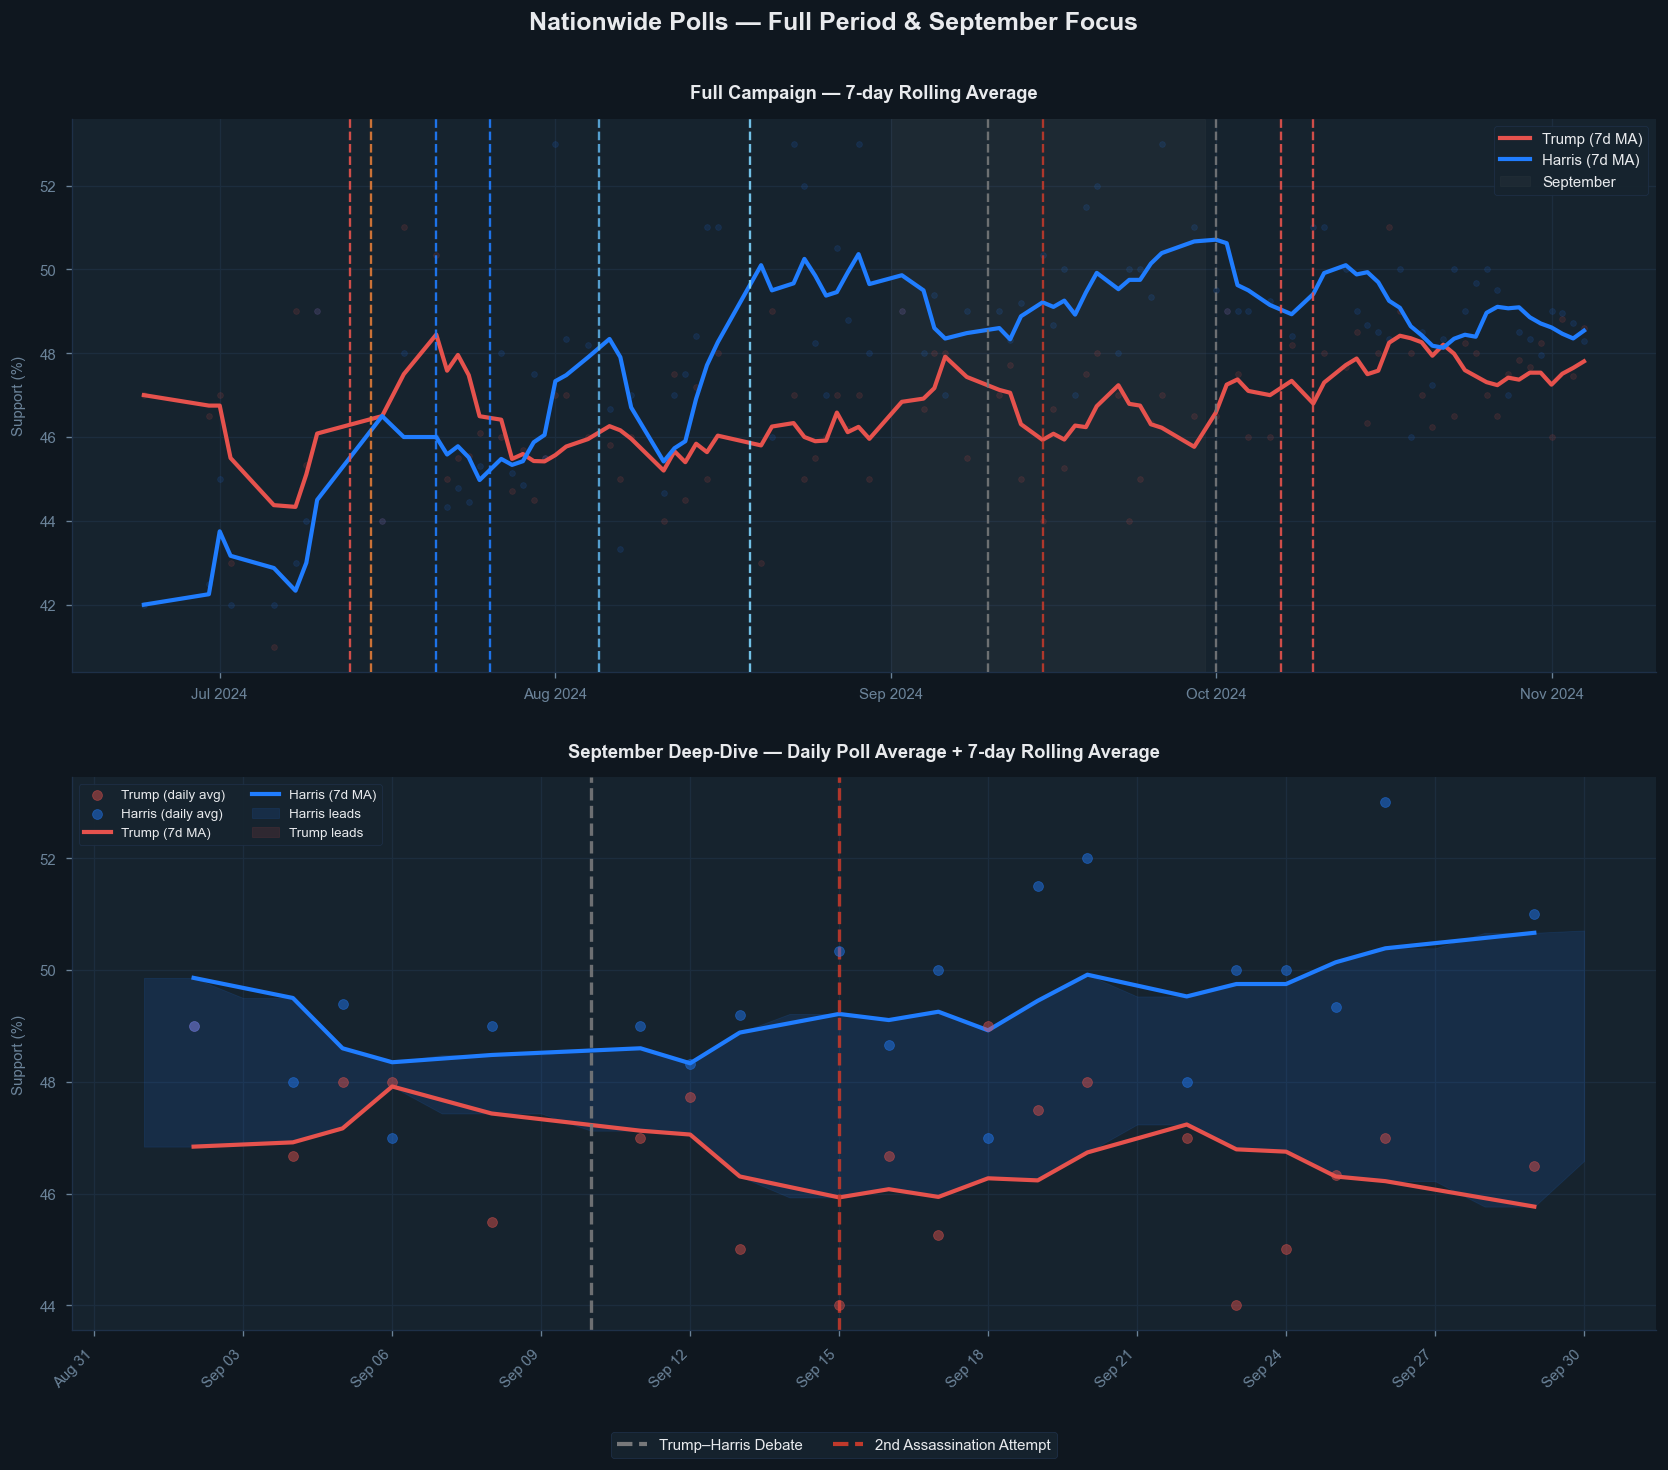

September polls  : n=51
Harris avg: 49.3% | Trump avg: 46.5%


In [ ]:
# Aggregate multiple polls on the same date -> daily mean first, then 7d rolling
# (multiple pollsters often release on the same day -> duplicate Date index -> ValueError)
df_p_raw = polls.dropna(subset=["Trump", "Harris"]).copy()
df_p_raw["Date"] = pd.to_datetime(df_p_raw["Date"])
df_p     = df_p_raw.groupby("Date")[["Trump", "Harris"]].mean().sort_index()

trump_roll  = df_p["Trump"].rolling("7D",  min_periods=1).mean()
harris_roll = df_p["Harris"].rolling("7D", min_periods=1).mean()

fig, axes = plt.subplots(2, 1, figsize=(14, 12))
fig.patch.set_facecolor(BG_DARK)
fig.suptitle("Nationwide Polls — Full Period & September Focus",
             color=TEXT_PRIMARY, fontsize=15, fontweight="bold", y=1.01)

# Panel 1: Full period
ax = axes[0]
ax.set_facecolor(BG_PANEL)
for spine in ax.spines.values(): spine.set_edgecolor(SPINE_COLOR)
ax.scatter(df_p.index, df_p["Trump"],  color=REPUBLICAN, alpha=0.12, s=12, zorder=2)
ax.scatter(df_p.index, df_p["Harris"], color=DEMOCRAT,   alpha=0.12, s=12, zorder=2)
ax.plot(trump_roll,  color=REPUBLICAN, linewidth=2.5, label="Trump (7d MA)")
ax.plot(harris_roll, color=DEMOCRAT,   linewidth=2.5, label="Harris (7d MA)")
ax.axvspan(pd.Timestamp("2024-09-01"), pd.Timestamp("2024-09-30"),
           color=NEUTRAL, alpha=0.08, label="September")
add_events(ax)
ax.set_title("Full Campaign — 7-day Rolling Average", color=TEXT_PRIMARY,
             fontsize=11, fontweight="bold")
ax.set_ylabel("Support (%)", color=TEXT_MUTED, fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.tick_params(colors=TEXT_MUTED)
ax.grid(axis="y", color="#1c2d3e", linewidth=0.8); ax.set_axisbelow(True)
ax.legend(facecolor=BG_PANEL, edgecolor=SPINE_COLOR, labelcolor=TEXT_PRIMARY, fontsize=9)

# Panel 2: September zoom
ax2 = axes[1]
ax2.set_facecolor(BG_PANEL)
for spine in ax2.spines.values(): spine.set_edgecolor(SPINE_COLOR)

sep_mask = (df_p.index >= "2024-09-01") & (df_p.index <= "2024-09-30")
ax2.scatter(df_p[sep_mask].index, df_p[sep_mask]["Trump"],
            color=REPUBLICAN, alpha=0.45, s=35, zorder=3, label="Trump (daily avg)")
ax2.scatter(df_p[sep_mask].index, df_p[sep_mask]["Harris"],
            color=DEMOCRAT,   alpha=0.45, s=35, zorder=3, label="Harris (daily avg)")
ax2.plot(trump_roll[sep_mask],  color=REPUBLICAN, linewidth=2.5, label="Trump (7d MA)")
ax2.plot(harris_roll[sep_mask], color=DEMOCRAT,   linewidth=2.5, label="Harris (7d MA)")

# fill_between on a daily DatetimeIndex -> guaranteed unique, no duplicates
sep_rng   = pd.date_range("2024-09-01", "2024-09-30")
tr_interp = trump_roll.reindex(sep_rng, method="nearest")
ha_interp = harris_roll.reindex(sep_rng, method="nearest")
ax2.fill_between(sep_rng, tr_interp, ha_interp,
                 where=(ha_interp >= tr_interp), color=DEMOCRAT,   alpha=0.12, label="Harris leads")
ax2.fill_between(sep_rng, tr_interp, ha_interp,
                 where=(ha_interp <  tr_interp), color=REPUBLICAN, alpha=0.12, label="Trump leads")

for lbl, date, color in ERA_EVENTS:
    ax2.axvline(pd.Timestamp(date), color=color, linestyle="--", linewidth=2, alpha=0.9)

ax2.set_title("September Deep-Dive — Daily Poll Average + 7-day Rolling Average",
              color=TEXT_PRIMARY, fontsize=11, fontweight="bold")
ax2.set_ylabel("Support (%)", color=TEXT_MUTED, fontsize=9)
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax2.xaxis.set_major_locator(mdates.DayLocator(interval=3))
plt.setp(ax2.get_xticklabels(), rotation=45, ha="right", color=TEXT_MUTED)
ax2.tick_params(colors=TEXT_MUTED)
ax2.grid(axis="y", color="#1c2d3e", linewidth=0.8); ax2.set_axisbelow(True)
ax2.legend(facecolor=BG_PANEL, edgecolor=SPINE_COLOR, labelcolor=TEXT_PRIMARY, fontsize=8, ncol=2)

fig.legend(handles=era_legend_handles(), loc="lower center",
           bbox_to_anchor=(0.5, 0.0), ncol=2,
           facecolor=BG_PANEL, edgecolor=SPINE_COLOR,
           labelcolor=TEXT_PRIMARY, fontsize=9, framealpha=0.95)
plt.tight_layout(rect=[0, 0.04, 1, 1], h_pad=2.5)
plt.show()

sep_polls = polls[(polls["Date"] >= "2024-09-01") & (polls["Date"] <= "2024-09-30")]
print(f"September polls  : n={len(sep_polls)}")
print(f"Harris avg: {sep_polls['Harris'].mean():.1f}% | Trump avg: {sep_polls['Trump'].mean():.1f}%")

**Interpretation.** September is Harris's strongest polling month in the entire campaign. The 7-day rolling average reaches its peak in the weeks surrounding the debate, with Harris consistently polling above 49% and holding a margin of 1–3 percentage points over Trump.

Importantly, polls did **not** show a dramatic response to either individual event in this era. This is consistent with the broader academic finding that polling is a slow-moving signal — it reflects the accumulated weight of weeks of impressions, not overnight reactions to individual events. The post-debate Harris lead is real, but it builds on the already-existing momentum from her nomination (Aug 5) rather than originating from the debate itself.

The assassination attempt on Sep 15 is **not visible as a downturn** in Harris's poll numbers — at least not within September. Any erosion of her lead that occurred in October was a slower-moving phenomenon, likely driven by late-campaign Trump momentum and the structural Republican advantage in key swing states.

---
## 5 · Partisan Newspaper Framing of the Debate

Democratic- and Republican-leaning outlets cover the same events through different frames.
Using daily VADER sentiment scores aggregated by media leaning, we track:
1. **Sentiment by leaning** (dem / rep / center) for Sep 1–25
2. **Divergence index** = `vader_compound_dem − vader_compound_rep` — positive = Democratic outlets more positive
3. **NRC Fear & Anger** by leaning — which side's headlines became more emotionally charged?

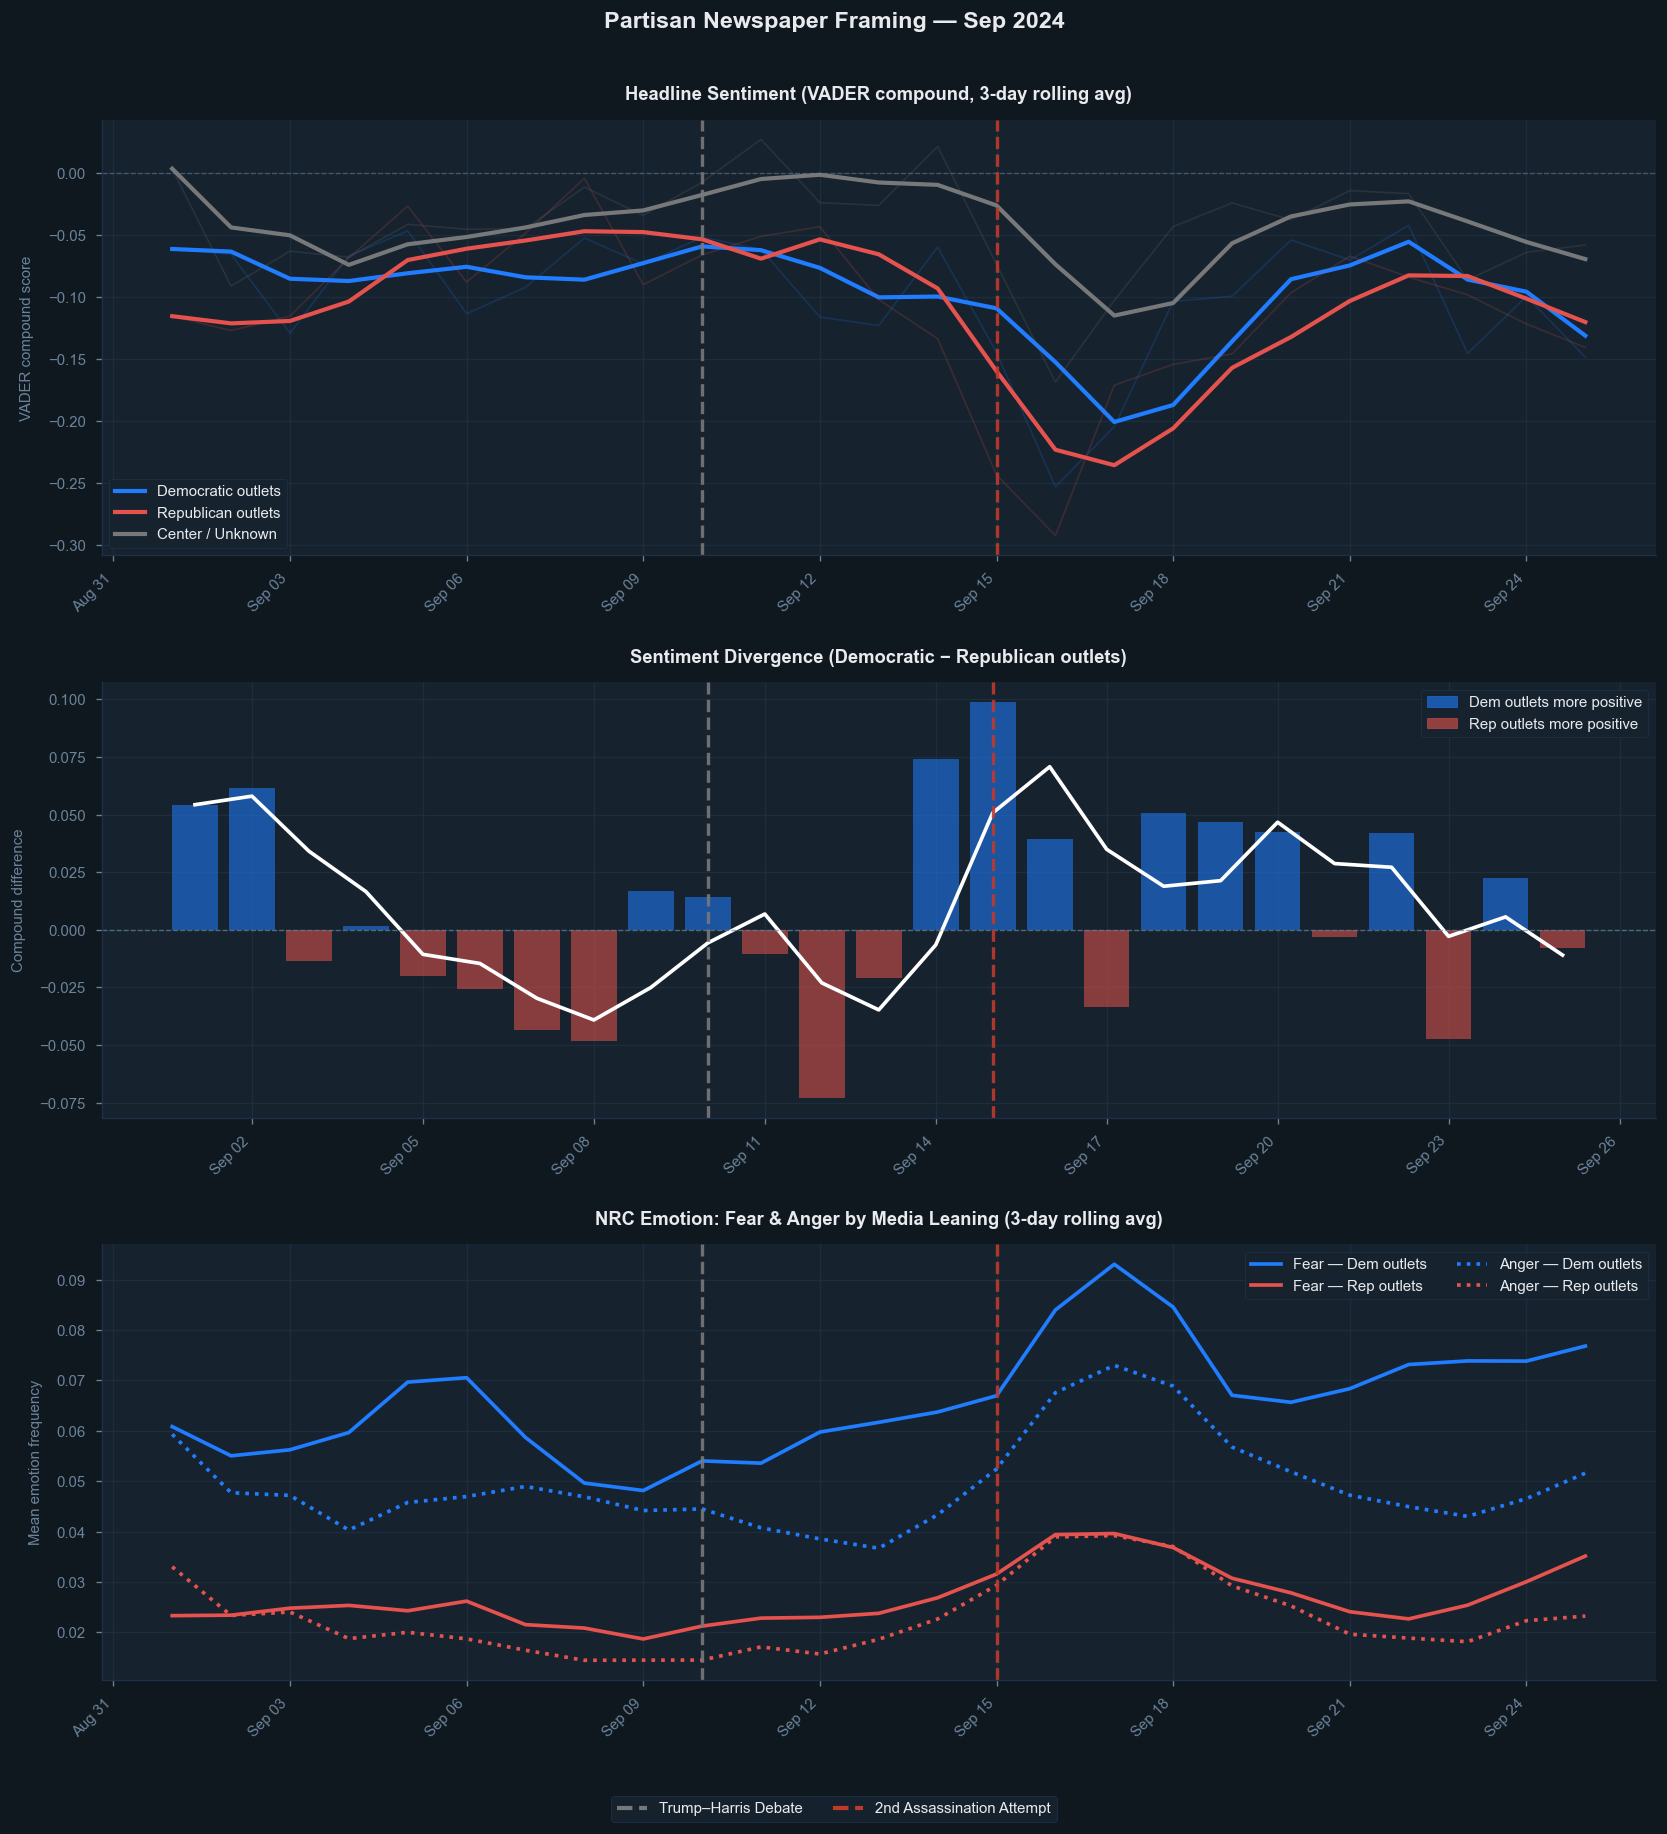

In [ ]:
ns_era = news_sent[
    (news_sent['date'] >= ERA_START) & (news_sent['date'] <= ERA_END)
].copy().sort_values('date').reset_index(drop=True)

ns_era['divergence'] = ns_era['vader_compound_mean_dem'] - ns_era['vader_compound_mean_rep']

# 3-day rolling smoothing
smooth_cols = ['vader_compound_mean_dem', 'vader_compound_mean_rep',
               'vader_compound_mean_cen', 'divergence',
               'nrc_fear_dem', 'nrc_fear_rep', 'nrc_anger_dem', 'nrc_anger_rep']
for c in smooth_cols:
    if c in ns_era.columns:
        ns_era[f'{c}_r3'] = ns_era[c].rolling(3, min_periods=1).mean()

fig, axes = plt.subplots(3, 1, figsize=(14, 15))
fig.patch.set_facecolor(BG_DARK)
fig.suptitle('Partisan Newspaper Framing — Sep 2024',
             color=TEXT_PRIMARY, fontsize=14, fontweight='bold', y=1.01)

LEAN_C = {'dem': DEMOCRAT, 'rep': REPUBLICAN, 'cen': NEUTRAL}
LEAN_L = {'dem': 'Democratic outlets', 'rep': 'Republican outlets', 'cen': 'Center / Unknown'}

# ── Panel 1: VADER compound by leaning ────────────────────────────────────────
ax = axes[0]
ax.set_facecolor(BG_PANEL)
for spine in ax.spines.values(): spine.set_edgecolor(SPINE_COLOR)
for lean in ['dem', 'rep', 'cen']:
    raw = f'vader_compound_mean_{lean}'
    smt = f'{raw}_r3'
    if raw not in ns_era.columns:
        continue
    ax.plot(ns_era['date'], ns_era[raw], color=LEAN_C[lean], alpha=0.18, linewidth=1)
    ax.plot(ns_era['date'], ns_era[smt], color=LEAN_C[lean], linewidth=2.5, label=LEAN_L[lean])
ax.axhline(0, color=TEXT_MUTED, linestyle='--', linewidth=0.8, alpha=0.5)
ax.set_title('Headline Sentiment (VADER compound, 3-day rolling avg)',
             color=TEXT_PRIMARY, fontsize=11, fontweight='bold')
ax.set_ylabel('VADER compound score', color=TEXT_MUTED, fontsize=9)
ax.legend(facecolor=BG_PANEL, edgecolor=SPINE_COLOR, labelcolor=TEXT_PRIMARY, fontsize=9)
ax.tick_params(colors=TEXT_MUTED)
ax.grid(axis='y', color='#1c2d3e', linewidth=0.8); ax.set_axisbelow(True)

# ── Panel 2: Divergence (Dem − Rep) ───────────────────────────────────────────
ax2 = axes[1]
ax2.set_facecolor(BG_PANEL)
for spine in ax2.spines.values(): spine.set_edgecolor(SPINE_COLOR)
bar_colors = [DEMOCRAT if v >= 0 else REPUBLICAN for v in ns_era['divergence']]
ax2.bar(ns_era['date'], ns_era['divergence'],
        color=bar_colors, alpha=0.55, width=0.8, edgecolor='none')
ax2.plot(ns_era['date'], ns_era['divergence_r3'], color='white', linewidth=2.2)
ax2.axhline(0, color=TEXT_MUTED, linestyle='--', linewidth=0.8, alpha=0.7)
ax2.set_title('Sentiment Divergence (Democratic − Republican outlets)',
              color=TEXT_PRIMARY, fontsize=11, fontweight='bold')
ax2.set_ylabel('Compound difference', color=TEXT_MUTED, fontsize=9)
ax2.tick_params(colors=TEXT_MUTED)
ax2.grid(axis='y', color='#1c2d3e', linewidth=0.8); ax2.set_axisbelow(True)
pos_p = mpatches.Patch(color=DEMOCRAT,   alpha=0.6, label='Dem outlets more positive')
neg_p = mpatches.Patch(color=REPUBLICAN, alpha=0.6, label='Rep outlets more positive')
ax2.legend(handles=[pos_p, neg_p], facecolor=BG_PANEL, edgecolor=SPINE_COLOR,
           labelcolor=TEXT_PRIMARY, fontsize=9)

# ── Panel 3: NRC Fear & Anger by leaning ─────────────────────────────────────
ax3 = axes[2]
ax3.set_facecolor(BG_PANEL)
for spine in ax3.spines.values(): spine.set_edgecolor(SPINE_COLOR)
emotion_series = [
    ('nrc_fear_dem_r3',  DEMOCRAT,   '-',  'Fear — Dem outlets'),
    ('nrc_fear_rep_r3',  REPUBLICAN, '-',  'Fear — Rep outlets'),
    ('nrc_anger_dem_r3', DEMOCRAT,   ':',  'Anger — Dem outlets'),
    ('nrc_anger_rep_r3', REPUBLICAN, ':',  'Anger — Rep outlets'),
]
for col, color, ls, lbl in emotion_series:
    if col in ns_era.columns:
        ax3.plot(ns_era['date'], ns_era[col], color=color, linestyle=ls,
                 linewidth=2.2, label=lbl)
ax3.set_title('NRC Emotion: Fear & Anger by Media Leaning (3-day rolling avg)',
              color=TEXT_PRIMARY, fontsize=11, fontweight='bold')
ax3.set_ylabel('Mean emotion frequency', color=TEXT_MUTED, fontsize=9)
ax3.legend(facecolor=BG_PANEL, edgecolor=SPINE_COLOR, labelcolor=TEXT_PRIMARY,
           fontsize=9, ncol=2)
ax3.tick_params(colors=TEXT_MUTED)
ax3.grid(axis='y', color='#1c2d3e', linewidth=0.8); ax3.set_axisbelow(True)

# Event lines on all panels
for ax in axes:
    for lbl, date, color in ERA_EVENTS:
        ax.axvline(pd.Timestamp(date), color=color, linestyle='--', linewidth=2, alpha=0.9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right', color=TEXT_MUTED)

fig.legend(handles=era_legend_handles(), loc='lower center',
           bbox_to_anchor=(0.5, 0.0), ncol=2,
           facecolor=BG_PANEL, edgecolor=SPINE_COLOR,
           labelcolor=TEXT_PRIMARY, fontsize=9, framealpha=0.95)
plt.tight_layout(rect=[0, 0.04, 1, 1], h_pad=2)
plt.show()

**Interpretation.** The newspaper sentiment data tells a nuanced story that does not match simple partisan intuitions.

**Panel 1 (VADER by leaning):** Both outlet types remained in negative sentiment territory throughout September. On debate day (Sep 10), Republican outlets were slightly more negative than Democratic ones (−0.064 vs −0.046). The day after the debate (Sep 11), this *reversed*: Republican outlets became *less* negative (−0.037) while Democratic outlets stayed at −0.055. This may reflect Republican media pivoting to spin Trump’s performance positively or amplify debate controversies rather than concede a loss. By Sep 12–13, Democratic outlets had grown notably more negative (−0.116, −0.122) — possibly reflecting post-debate electoral anxiety.

**Panel 2 (divergence index):** After the assassination attempt (Sep 15–16), both outlets crashed to their most negative readings of the era, but Republican outlets went *more* negative than Democratic ones: −0.230 vs −0.155 on Sep 15; −0.306 vs −0.256 on Sep 16. The divergence (Dem − Rep) flipped *positive* after the attempt — Democratic outlets were comparatively less negative. For right-leaning media, an assassination attempt on their candidate triggers outrage coverage that amplifies negativity far beyond the opposition’s response.

**Panel 3 (NRC Fear & Anger):** The Sep 15–16 spike is clear and asymmetric. Republican outlets show higher fear (0.107 vs 0.090 on Sep 15; 0.128 vs 0.121 on Sep 16) and substantially higher anger (0.090 vs 0.069 on Sep 15; 0.117 vs 0.092 on Sep 16) than Democratic outlets. The debate itself (Sep 10) produced no notable fear/anger spike in either outlet type — consistent with a watched, expected event rather than an emotional shock.

---
## 5b · Newspaper Agenda-Setting — Debate vs Assassination Coverage by Leaning

How much did Democratic, Republican, and Center outlets cover each event?
A symmetric response suggests all outlets treated the event equally; asymmetry reveals **partisan agenda-setting**.


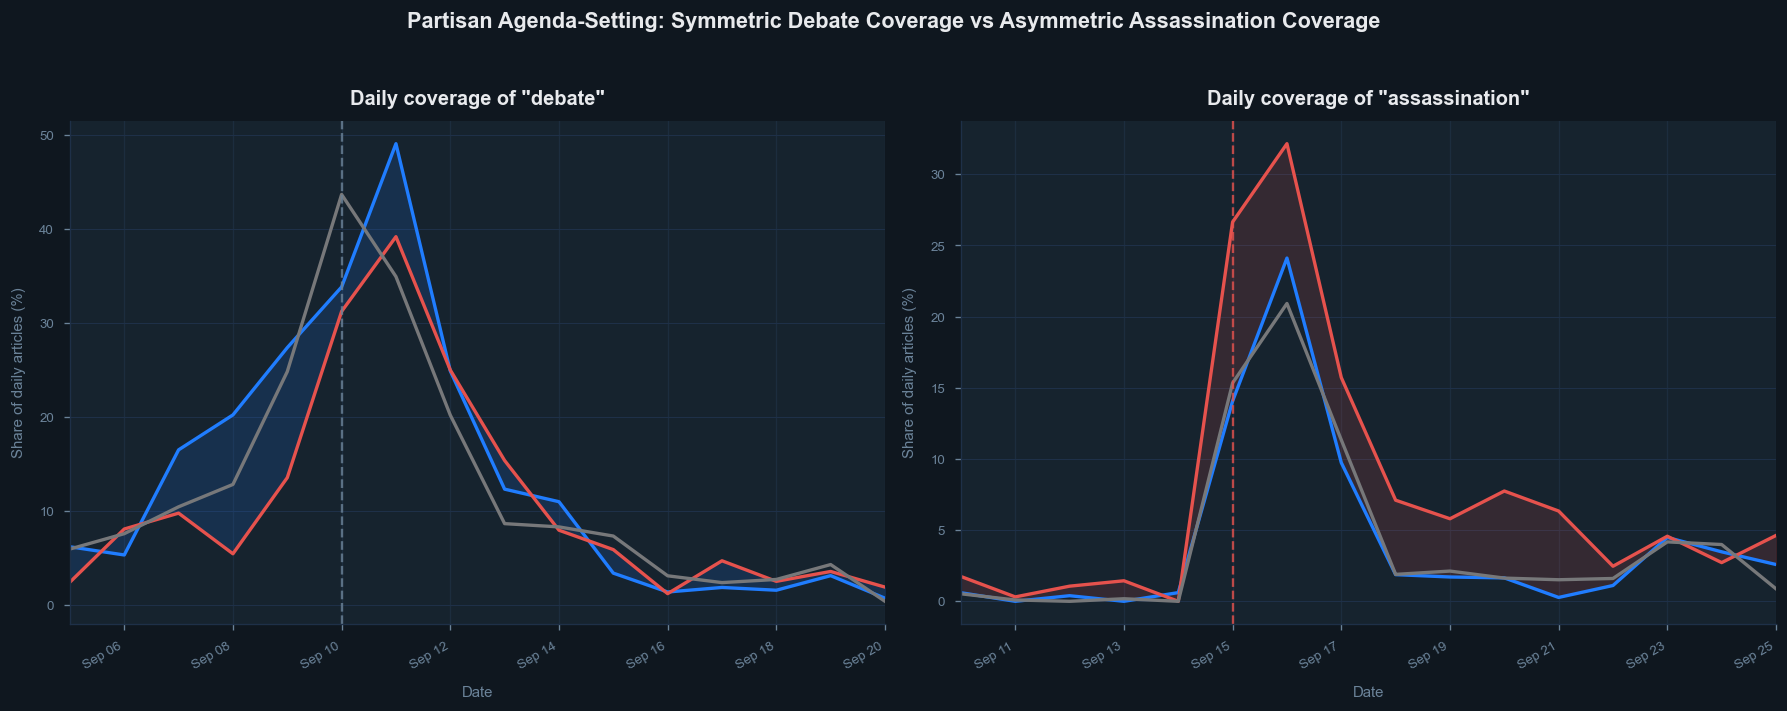

In [ ]:
# ── Section 5b: Newspaper agenda-setting — daily term frequency by leaning ────
# Load full articles for term-frequency analysis (~230k rows)
articles = pd.read_csv(ROOT / '2_Silver/Newspapers/mediacloud_articles_clean.csv',
                       parse_dates=['date'])

# Restrict to Sep 5 – Sep 25 (debate window Sep 5–20, assassination window Sep 10–25)
art = articles[(articles['date'] >= '2024-09-05') &
               (articles['date'] <= '2024-09-25')].copy()

# Daily article totals per leaning (for normalisation)
daily_totals = art.groupby(['date', 'leaning']).size().reset_index(name='total')

TERMS       = ['debate', 'assassination']
LEAN_ORDER  = ['Democratic', 'Republican', 'Center/Unknown']
LEAN_LABELS = ['Democratic', 'Republican', 'Center']
LEAN_COLORS = [DEMOCRAT, REPUBLICAN, NEUTRAL]
FILL_COLORS = {'debate': DEMOCRAT, 'assassination': REPUBLICAN}
# Each panel uses its own x-window so the event falls at the same 1/3 position
XLIMS       = {'debate': (pd.Timestamp('2024-09-05'), pd.Timestamp('2024-09-20')),
               'assassination': (pd.Timestamp('2024-09-10'), pd.Timestamp('2024-09-25'))}

term_daily = {}
for term in TERMS:
    tmask = art['title_clean'].str.contains(term, case=False, na=False, regex=False)
    d = art[tmask].groupby(['date', 'leaning']).size().reset_index(name='count')
    d = d.merge(daily_totals, on=['date', 'leaning'])
    d['share_pct'] = d['count'] / d['total'] * 100
    idx = pd.date_range('2024-09-05', '2024-09-25')
    rows = []
    for lean in LEAN_ORDER:
        sub = d[d['leaning'] == lean].set_index('date')['share_pct'].reindex(idx, fill_value=0)
        rows.append(sub.rename(lean))
    term_daily[term] = pd.concat(rows, axis=1)

# ── Plot ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.patch.set_facecolor(BG_DARK)

for ax, term in zip(axes, TERMS):
    ax.set_facecolor(BG_PANEL)
    for sp in ax.spines.values():
        sp.set_edgecolor(SPINE_COLOR)

    x0, x1 = XLIMS[term]
    df_t = term_daily[term].loc[x0:x1]

    # Lines (no dots)
    for lean, label, color in zip(LEAN_ORDER, LEAN_LABELS, LEAN_COLORS):
        ax.plot(df_t.index, df_t[lean].values, color=color,
                linewidth=2.0, label=label)

    # Fill between Democratic and Republican lines
    ax.fill_between(df_t.index, df_t['Democratic'], df_t['Republican'],
                    color=FILL_COLORS[term], alpha=0.15)

    # Event vertical line
    for ev_date, ev_label, ev_color in EVENTS_MARK[term]:
        ax.axvline(pd.Timestamp(ev_date), color=ev_color,
                   linestyle='--', linewidth=1.4, alpha=0.8)

    ax.set_xlim(x0, x1)
    ax.set_title(PANEL_TITLES[term], color=TEXT_PRIMARY,
                 fontsize=12, fontweight='bold', pad=10)
    ax.set_ylabel('Share of daily articles (%)', color=TEXT_MUTED, fontsize=9)
    ax.set_xlabel('Date', color=TEXT_MUTED, fontsize=9)
    ax.tick_params(colors=TEXT_MUTED, labelsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
    ax.grid(axis='y', color=SPINE_COLOR, linewidth=0.6)
    ax.set_axisbelow(True)

fig.suptitle(
    'Partisan Agenda-Setting: Symmetric Debate Coverage vs Asymmetric Assassination Coverage',
    color=TEXT_PRIMARY, fontsize=13, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

**Interpretation — Partisan Agenda-Setting in Era 3.**

The daily view removes any aggregation ambiguity and reveals two sharply contrasting editorial patterns.

**Debate (Sep 10) — broadly symmetric, with a Democratic lean in the aftermath.**
All three outlet groups spiked on debate day (Sep 10): Center 43%, Democratic 33%, Republican 31% — roughly equal. The day after (Sep 11), Democratic outlets wrote about the debate the most (48.8% vs. 38.1% for Republican), consistent with their candidate having been widely seen as the debate winner. Coverage fell back to baseline by Sep 13.

**Assassination attempt (Sep 15) — Republican amplification from day one.**
On the day of the assassination attempt itself, Republican outlets already devoted **26.6%** of their articles to it, compared to 14.1% for Democratic and 15.3% for Center outlets — nearly double. This gap persisted through the week: Sep 16 (Rep 32.1% vs. Dem 23.9%), Sep 17 (Rep 15.3% vs. Dem 9.7%), and even into Sep 18–20 where Republican coverage remained around 5–7% while Democratic outlets had already moved on (1.5–2%).

This is consistent with **partisan agenda-setting theory**: Republican media amplified an event that generated political sympathy for Trump, while Democratic outlets returned to other topics more quickly. The pre-Sep 15 near-zero values for "assassination" confirm there was no anticipatory coverage — the divergence started exactly on the event day.

*Methodological note:* Shares are normalised by total daily article volume per leaning group. Days with very few articles (e.g. weekends) can produce noisier estimates.


---
## 6 · Google Trends — Transient Attention Spikes

Google Trends measures *information-seeking* — what people actively searched for — rather than *expression*.
A structural event (like Biden's withdrawal) creates a lasting search shift because the public needs to keep learning about a new candidate.
A transient event (like a debate or assassination attempt) creates a spike that decays once curiosity is satisfied.

We show: (1) raw search interest Sep 1–25 by keyword; (2) spike-and-decay curves for three events indexed to event day = 1.0.

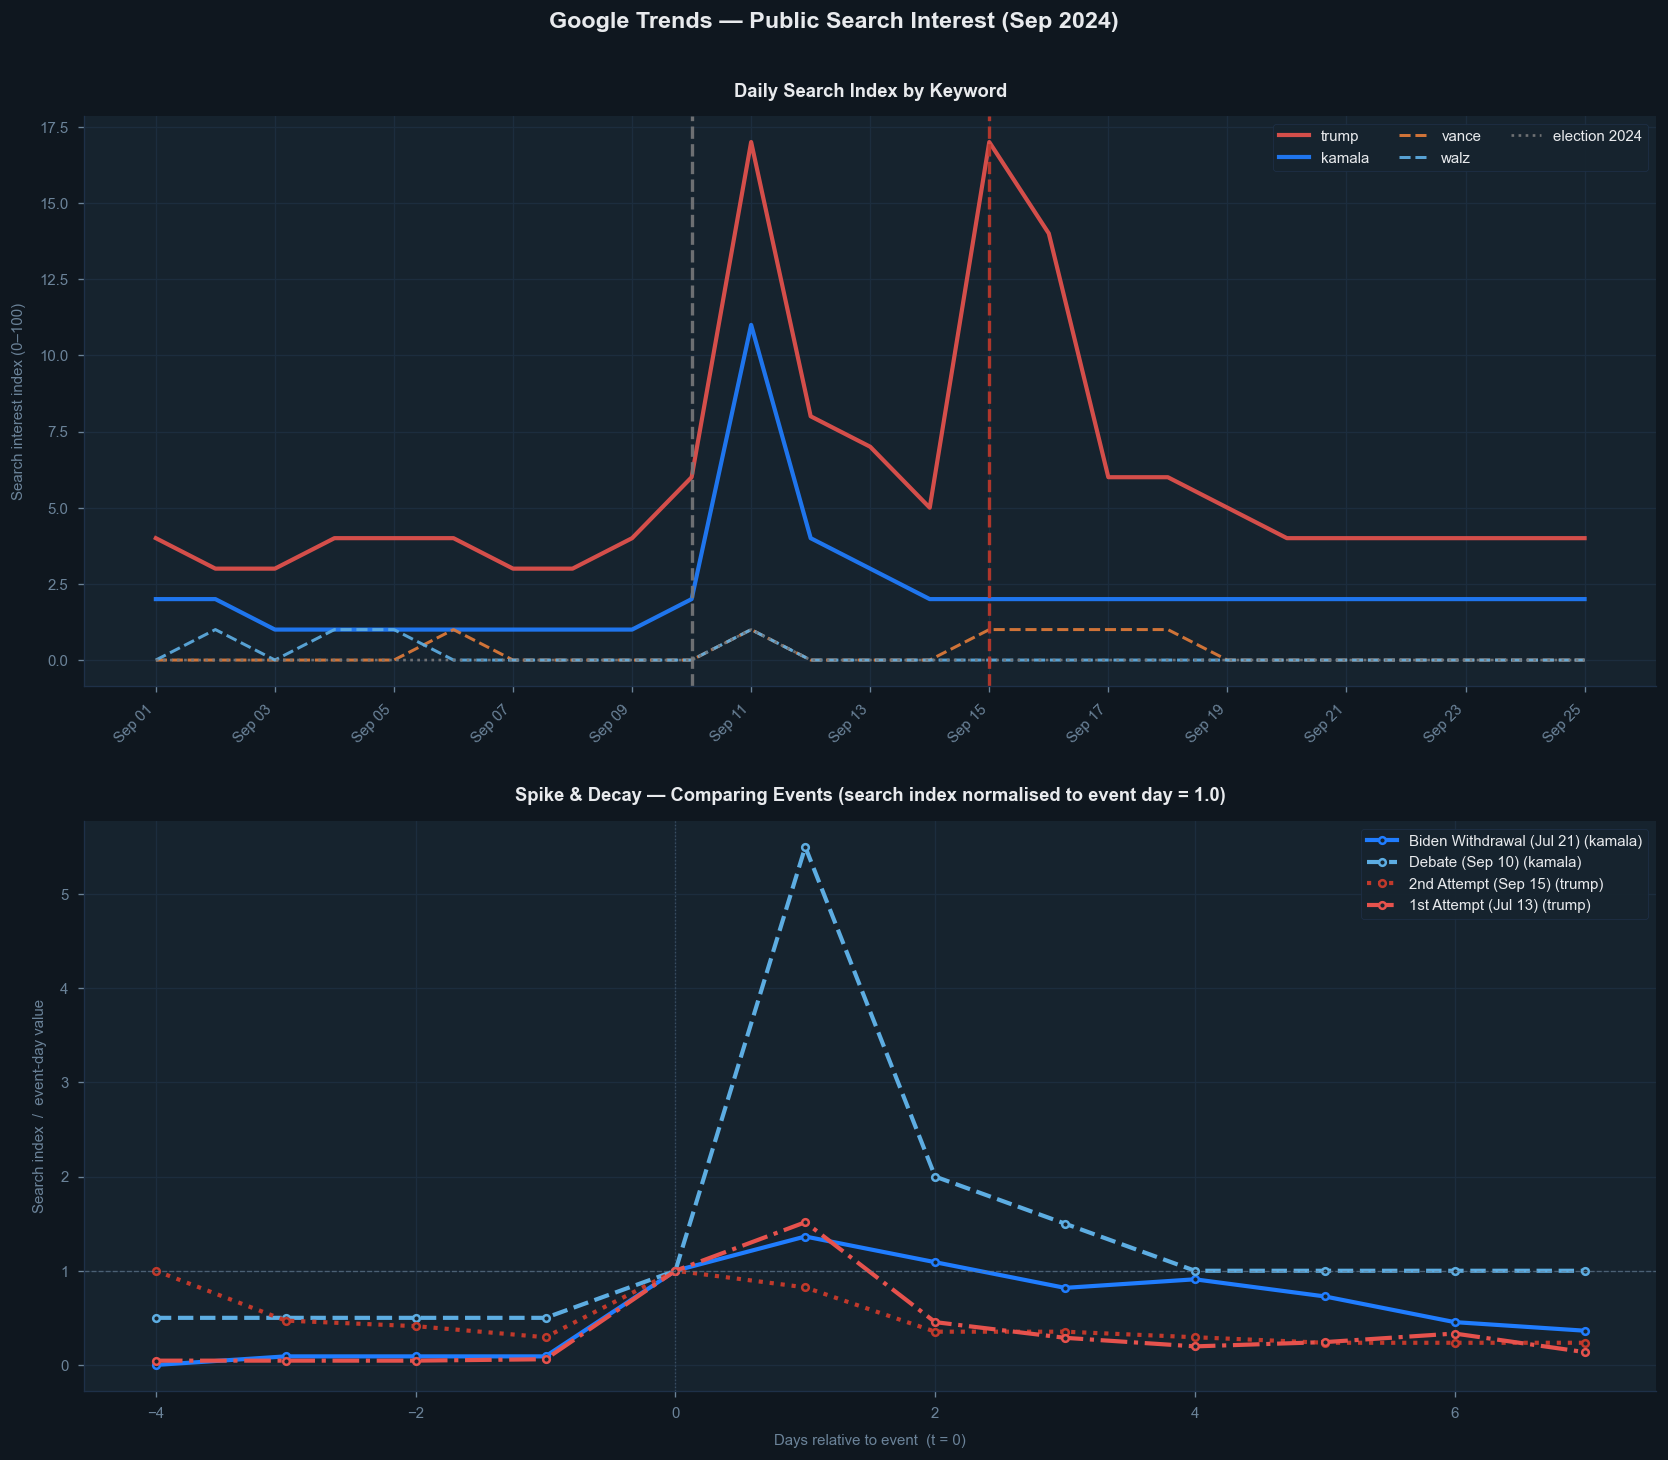

In [ ]:
trends_era = trends[
    (trends['date'] >= ERA_START) & (trends['date'] <= ERA_END)
].copy()

fig, axes = plt.subplots(2, 1, figsize=(14, 12))
fig.patch.set_facecolor(BG_DARK)
fig.suptitle('Google Trends — Public Search Interest (Sep 2024)',
             color=TEXT_PRIMARY, fontsize=14, fontweight='bold', y=1.01)

TREND_STYLE = {
    'trump':         (REPUBLICAN, '-',  2.5),
    'kamala':        (DEMOCRAT,   '-',  2.5),
    'vance':         ('#e07b39',  '--', 1.8),
    'walz':          ('#5dade2',  '--', 1.8),
    'election 2024': (NEUTRAL,    ':',  1.6),
}

# ── Panel 1: Sep 1–25 search index ───────────────────────────────────────────
ax = axes[0]
ax.set_facecolor(BG_PANEL)
for spine in ax.spines.values(): spine.set_edgecolor(SPINE_COLOR)
for kw, (color, ls, lw) in TREND_STYLE.items():
    if kw in trends_era.columns:
        ax.plot(trends_era['date'], trends_era[kw],
                color=color, linestyle=ls, linewidth=lw, label=kw, alpha=0.92)
for lbl, date, color in ERA_EVENTS:
    ax.axvline(pd.Timestamp(date), color=color, linestyle='--', linewidth=2, alpha=0.9)
ax.set_title('Daily Search Index by Keyword', color=TEXT_PRIMARY, fontsize=11, fontweight='bold')
ax.set_ylabel('Search interest index (0–100)', color=TEXT_MUTED, fontsize=9)
ax.tick_params(colors=TEXT_MUTED)
ax.legend(facecolor=BG_PANEL, edgecolor=SPINE_COLOR, labelcolor=TEXT_PRIMARY, fontsize=9, ncol=3)
ax.grid(axis='y', color='#1c2d3e', linewidth=0.8); ax.set_axisbelow(True)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
plt.setp(ax.get_xticklabels(), rotation=45, ha='right', color=TEXT_MUTED)

# ── Panel 2: Spike-and-decay comparison ──────────────────────────────────────
ax2 = axes[1]
ax2.set_facecolor(BG_PANEL)
for spine in ax2.spines.values(): spine.set_edgecolor(SPINE_COLOR)

SPIKE_COMPARE = [
    ('Biden Withdrawal (Jul 21)',  '2024-07-21', 'kamala', DEMOCRAT,   '-'),
    ('Debate (Sep 10)',            '2024-09-10', 'kamala', '#5dade2',  '--'),
    ('2nd Attempt (Sep 15)',       '2024-09-15', 'trump',  '#c0392b',  ':'),
    ('1st Attempt (Jul 13)',       '2024-07-13', 'trump',  REPUBLICAN, '-.'),
]

for lbl, date_str, kw, color, ls in SPIKE_COMPARE:
    ev  = pd.Timestamp(date_str)
    win = trends[
        (trends['date'] >= ev - pd.Timedelta(days=4)) &
        (trends['date'] <= ev + pd.Timedelta(days=7))
    ].copy()
    if win.empty or kw not in win.columns:
        continue
    win = win.set_index('date').sort_index()
    # find base value on or nearest to event day
    available = win.index
    base_date = available[np.argmin(np.abs((available - ev).days))]
    base_val  = win.loc[base_date, kw]
    if base_val == 0:
        continue
    rel  = (win.index - ev).days
    vals = win[kw] / base_val
    ax2.plot(rel, vals, color=color, linestyle=ls, linewidth=2.5,
             marker='o', markersize=4,
             markerfacecolor=BG_PANEL, markeredgecolor=color, markeredgewidth=1.5,
             label=f'{lbl} ({kw})')

ax2.axhline(1.0, color=TEXT_MUTED, linestyle='--', linewidth=0.8, alpha=0.6)
ax2.axvline(0,   color=TEXT_MUTED, linestyle=':',  linewidth=0.8, alpha=0.4)
ax2.set_xlabel('Days relative to event  (t = 0)', color=TEXT_MUTED, fontsize=9)
ax2.set_ylabel('Search index  /  event-day value', color=TEXT_MUTED, fontsize=9)
ax2.set_title('Spike & Decay — Comparing Events (search index normalised to event day = 1.0)',
              color=TEXT_PRIMARY, fontsize=11, fontweight='bold')
ax2.tick_params(colors=TEXT_MUTED)
ax2.legend(facecolor=BG_PANEL, edgecolor=SPINE_COLOR, labelcolor=TEXT_PRIMARY, fontsize=9)
ax2.grid(color='#1c2d3e', linewidth=0.8); ax2.set_axisbelow(True)

plt.tight_layout(h_pad=2.5)
plt.show()

**Interpretation.** Google Trends makes the *structural vs transient* distinction concrete and confirms the assassination fatigue narrative quantitatively.

**Panel 1** confirms Trump’s absolute search dominance throughout September. The spike pattern is informative: on debate day itself (Sep 10), both Trump and Kamala were at modest levels (trump=6, kamala=2). The spike arrived *the next day* (Sep 11): trump=16, kamala=11 — searches peaked as people read recaps and fact-checks, not while watching live. For the assassination attempt (Sep 15), only Trump spiked (trump=17, kamala=2); Kamala’s search interest stayed flat. This asymmetry mirrors the Bluesky finding: the assassination attempt generated Trump-only attention.

**Panel 2** — the spike-and-decay comparison — quantifies the fatigue hypothesis precisely. The **first assassination attempt (Jul 13–14)** drove Trump’s index to 68 on the day and 100 (the maximum) the day after — a massive attention event with Kamala at zero. The **second attempt (Sep 15)** reached only 17 — less than a fifth of the first attempt’s peak — and decayed within two days. The public’s reaction was structurally shallower the second time.

Both events in this era produced classic transient spikes: steep rise, fast decay to baseline within 3–4 days. Neither created the persistent structural information demand seen after Biden’s withdrawal (when Kamala’s searches climbed and stayed elevated for weeks as the public continuously learned about a new candidate). Era 3 was dramatic; it was not structurally transformative.